## Cài đặt & Import thư viện

In [ ]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

import cv2
from PIL import Image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage import filters, feature

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from scipy import stats
import scipy.fftpack
from scipy.stats import kstest, ks_2samp, f_oneway

from concurrent.futures import ThreadPoolExecutor , as_completed
import multiprocessing, logging
from pathlib import Path
from collections import defaultdict

import gc

# Seed để tái hiện kết quả
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Import thư viện thành công!')

## Tải dữ liệu

In [ ]:
DATA_ROOT = './seg_train/seg_train'
CLASSES = sorted(os.listdir(DATA_ROOT))
print('Các lớp phát hiện:', CLASSES)

# Hàm tiện ích: load danh sách path ảnh
def get_image_paths(root, classes):
    data = []
    for cls in classes:
        paths = glob.glob(os.path.join(root, cls, '*.jpg')) + \
                glob.glob(os.path.join(root, cls, '*.png'))
        for p in paths:
            data.append({'path': p, 'label': cls})
    return pd.DataFrame(data)

df = get_image_paths(DATA_ROOT, CLASSES)
print(f'Tổng số ảnh: {len(df)}')
display(df.head())

# load ảnh về numpy
def load_image_rgb(path, size=None):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size:
        img = cv2.resize(img, (size, size))
    return img

# Hiển thị mẫu ảnh từ mỗi lớp
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    sample = df[df['label'] == cls].iloc[0]['path']
    img = load_image_rgb(sample)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Mẫu ảnh từ mỗi lớp', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Phần 2.1.3 – Kỹ thuật tiền xử lý & Ablation Study

**Phương pháp Ablation Study:** 
Với mỗi kỹ thuật tiền xử lý, nhóm dùng mô hình k-NN (với $k=5$) trên tập dữ liệu ảnh đã được làm phẳng (flattened). Trọng tâm của phương pháp là so sánh trực tiếp độ chính xác (accuracy) trước và sau khi áp dụng kỹ thuật nhằm đánh giá mức độ hiệu quả.


#### 4.1. Tại sao chọn k-NN (với k=5) làm mô hình cơ sở?

- **Tính nguyên bản của không gian đặc trưng (Non-parametric Baseline):**  
    k-NN là một thuật toán thuộc nhóm dựa trên khoảng cách (distance-based). Nó hoàn toàn không học các bộ tham số trọng số phức tạp mà thực hiện phân loại dựa trực tiếp vào vị trí hình học của các điểm dữ liệu trong không gian Euclid. Do đó, nếu một kỹ thuật tiền xử lý tốt thực sự cải thiện chất lượng dữ liệu, nó sẽ làm cho các điểm ảnh cùng lớp "cụm" lại gần nhau hơn, biểu hiện ngay lập tức qua việc tăng độ chính xác của k-NN.
- **Khả năng kiểm chứng tính phân tách (Separability):**  
    Hiệu suất của thuật toán k-NN phản chiếu độ sạch và tính tuyến tính/phi tuyến tính cơ bản của không gian đặc trưng. Nếu k-NN cho kết quả cực kỳ thấp trên ảnh gốc, điều đó khẳng định rằng các giá trị pixel thô (raw pixels) thiếu đi khả năng phân tách, tạo ra cơ sở lý luận vững chắc để sau đó đề xuất các kiến trúc và kỹ thuật tiên tiến hơn.

#### 4.2. Tại sao chọn độ phân giải trung gian $64 \times 64$?

Việc lựa chọn kích thước để đưa không gian hệ thống vào một tỷ lệ thống nhất ảnh hưởng nghiêm trọng đến tài nguyên.

- **Sự cân bằng giữa Thông tin và Chi phí (Information-Efficiency Trade-off):**
    - Ở mức siêu thấp ($32 \times 32$), các chi tiết tần số cao như các cạnh sắc nét của tòa nhà (Buildings) hoặc kết cấu tán lá (Forest) bị phá hủy do hiện tượng răng cưa.
    - Ở mức cao ($128 \times 128$ trở lên), số lượng chiều của một bức ảnh tăng theo cấp số nhân (khoảng $49,152$ chiều). Việc quá nhiều chiều này gây ra **Curse of Dimensionality**, khiến các phép tính khoảng cách Euclid tiệm cận về cùng một giá trị, làm k-NN suy giảm năng lực. Đồng thời, nó vượt quá ngưỡng tài nguyên RAM thông thường khi phải thực hiện chuẩn bị tập dữ liệu đầy đủ.
- **$64 \times 64$ là "điểm ngọt" (Sweet Spot):**  
    Giữ được xấp xỉ cấu trúc hình học (semantic shape), phân biệt rõ bầu trời và biển thông qua mức xanh, nhưng duy trì số chiều input ở ngưỡng vừa phải ($\approx 12,288$ chiều).

In [ ]:
images_by_class = {}
for cls in CLASSES:
    paths = df[df['label'] == cls]['path'].tolist()
    images_by_class[cls] = [load_image_rgb(p) for p in paths]

# === HÀM ABLATION STUDY DÙNG CHUNG ===

def run_classifier(X, y, model='knn', k=5):
    """
    Flatten ảnh và chạy k-NN hoặc Logistic Regression.
    Trả về accuracy trung bình cross-validation 5-fold.
    """
    X_flat = X.reshape(len(X), -1)
    if model == 'knn':
        clf = KNeighborsClassifier(n_neighbors=k)
    else:
        clf = LogisticRegression(max_iter=500, random_state=SEED)
    scores = cross_val_score(clf, X_flat, y, cv=5, scoring='accuracy', n_jobs=-1)
    return scores.mean(), scores.std()

# Chuẩn bị nhãn số
label2id = {cls: i for i, cls in enumerate(CLASSES)}

# Xây dựng X_base và y_base từ images_by_class (dùng size=64 làm baseline)
X_base, y_base = [], []
for cls in CLASSES:
    for img in images_by_class[cls]:
        X_base.append(img)
        y_base.append(label2id[cls])
        
# Chuẩn hóa toàn bộ ảnh về cùng shape trước khi chuyển sang numpy array
BASELINE_SIZE = 64

def _prepare_img(img, size=BASELINE_SIZE):
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

# X_base = np.stack([_prepare_img(img) for img in X_base]).astype(np.uint8)
# y_base = np.array(y_base)

# # Baseline accuracy
# baseline_acc, baseline_std = run_classifier(X_base, y_base, model='knn')
# print(f'Baseline k-NN Accuracy (64×64 RGB): {baseline_acc:.4f} ± {baseline_std:.4f}')

# # Dict lưu kết quả ablation
# ablation_results = {'Baseline (64×64 RGB)': baseline_acc}

# --
def build_dataset(size, max_per_class=None):
    imgs, labels = [], []
    for cls in CLASSES:
        img_list = images_by_class[cls]

        if max_per_class is not None:
            img_list = img_list[:max_per_class]

        for img in img_list:
            imgs.append(_prepare_img(img, size))
            labels.append(label2id[cls])
    return np.stack(imgs).astype(np.uint8), np.array(labels)

# Chạy trên 3 kích thước
MAX_PER_CLASS = 700  

size_config = [32, 64, 128, 150]

ablation_results_a = {}

for size in size_config:
    X_s, y_s = build_dataset(size, max_per_class=MAX_PER_CLASS)
    acc, std  = run_classifier(X_s, y_s, model='knn')
    key = f'Baseline ({size}×{size} RGB)'
    ablation_results_a[key] = acc
    print(f'{key}: {acc:.4f} ± {std:.4f}')
    if size == BASELINE_SIZE:
        X_base, y_base = X_s, y_s
        baseline_acc, baseline_std = acc, std

ablation_results = {'Baseline (64×64 RGB)': baseline_acc}

Baseline (32×32 RGB): 0.4419 ± 0.0128
Baseline (64×64 RGB): 0.4207 ± 0.0115
Baseline (128×128 RGB): 0.3962 ± 0.0136
Baseline (150×150 RGB): 0.3645 ± 0.0129


---
### 4a. Resize + Đo lường SSIM / PSNR

**Lý thuyết:**

Việc thay đổi kích thước ảnh (Resize) là bước tiền xử lý bắt buộc để đưa các ảnh về cùng một kích thước đầu vào cho mô hình học máy, đồng thời giảm thiểu chi phí tính toán. Tuy nhiên, quá trình này (hiện thực qua các phép nội suy - Interpolation) luôn dẫn đến sự mất mát thông tin cấu trúc. Để định lượng mức độ suy giảm chất lượng so với ảnh gốc, chúng ta sử dụng hai chỉ số đánh giá tiêu chuẩn sau:

**1. Chỉ số tương đồng cấu trúc (Structural Similarity Index - SSIM)**

Khác với các phương pháp đo lường sai số điểm ảnh truyền thống, SSIM đánh giá sự thay đổi về thông tin cấu trúc mô phỏng theo cảm nhận thị giác của con người. Thuật toán SSIM kết hợp đánh giá trên ba yếu tố cốt lõi: Độ chói (Luminance), Độ tương phản (Contrast) và Cấu trúc (Structure).

$$\text{SSIM}(x, y) = \frac{(2\mu_x \mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Trong đó:
- $\mu_x, \mu_y$: Giá trị trung bình của ảnh $x$ và $y$ (đại diện cho độ chói).
- $\sigma_x, \sigma_y$: Độ lệch chuẩn của ảnh (đại diện cho độ tương phản).
- $\sigma_{xy}$: Hiệp phương sai của hai ảnh (đại diện cho sự tương quan cấu trúc).
- $c_1, c_2$: Các hằng số ổn định toán học nhằm tránh lỗi chia cho không khi phương sai gần bằng 0.

*Tiêu chí đánh giá:* Giá trị $\text{SSIM} \in [-1, 1]$. Giá trị càng lân cận $1$ chứng tỏ ảnh sau resize càng bảo toàn trọn vẹn đặc trưng cấu trúc tự nhiên của ảnh gốc.

**2. Tỉ lệ tín hiệu cực đại trên nhiễu (Peak Signal-to-Noise Ratio - PSNR)**

PSNR đo lường chất lượng tái thiết lập của ảnh bằng cách định lượng cường độ tín hiệu khả dĩ tối đa so với mức độ nhiễu (sai số ngẫu nhiên) phát sinh do quá trình thu nhỏ/phóng to mảng pixel.

$$\text{PSNR} = 10 \cdot \log_{10}\left(\frac{\text{MAX}_I^2}{\text{MSE}}\right)$$

Trong đó:
- $\text{MAX}_I$: Giá trị pixel lớn nhất có thể hiển thị (ví dụ: $255$ đối với định dạng ảnh 8-bit).
- $\text{MSE}$ (Mean Squared Error): Tổng bình phương sai số trung bình giữa phân phối pixel của ảnh gốc và ảnh sau resize.

*Tiêu chí đánh giá:* PSNR được tính bằng đơn vị decibel (dB). Chỉ số PSNR càng cao khẳng định mức độ nhiễu kỹ thuật càng thấp, suy ra bức ảnh giữ được mức độ trung thực lý tưởng so với bản gốc.

Calculating SSIM/PSNR on Full Dataset: 100%|██████████| 13846/13846 [05:05<00:00, 45.31it/s] 


Kết quả SSIM và PSNR theo kích thước:
    Size |    SSIM Mean |   SSIM Std |    PSNR Mean |   PSNR Std
------------------------------------------------------------
      32 |       0.4850 |     0.1521 |        19.60 |       3.58
      64 |       0.6628 |     0.1124 |        21.96 |       3.72
     128 |       0.8564 |     0.0523 |        25.78 |       3.79


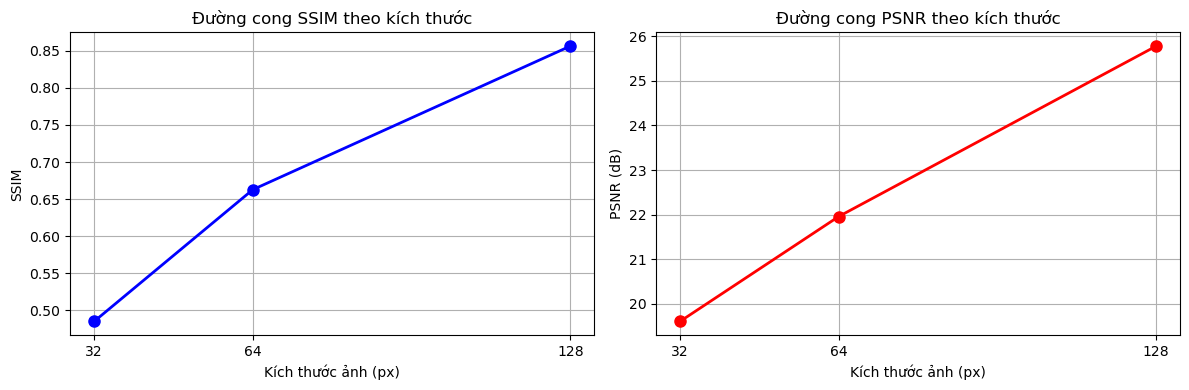


=== Ablation: k-NN Accuracy theo kích thước (full dataset, batched) ===

[Size 32×32]
  Fold 1/5 — train=11076, test=2770... acc=0.4697
  Fold 2/5 — train=11077, test=2769... acc=0.4760
  Fold 3/5 — train=11077, test=2769... acc=0.4713
  Fold 4/5 — train=11077, test=2769... acc=0.4727
  Fold 5/5 — train=11077, test=2769... acc=0.4756
→ k-NN Accuracy (size=32): 0.4731 ± 0.0024

[Size 64×64]
  Fold 1/5 — train=11076, test=2770... acc=0.4336
  Fold 2/5 — train=11077, test=2769... acc=0.4496
  Fold 3/5 — train=11077, test=2769... acc=0.4395
  Fold 4/5 — train=11077, test=2769... acc=0.4500
  Fold 5/5 — train=11077, test=2769... acc=0.4410
→ k-NN Accuracy (size=64): 0.4427 ± 0.0063

[Size 128×128]
  Fold 1/5 — train=11076, test=2770... acc=0.4029
  Fold 2/5 — train=11077, test=2769... acc=0.4196
  Fold 3/5 — train=11077, test=2769... acc=0.4117
  Fold 4/5 — train=11077, test=2769... acc=0.4251
  Fold 5/5 — train=11077, test=2769... acc=0.4063
→ k-NN Accuracy (size=128): 0.4131 ± 0.0082



In [9]:
# Hàm k-NN batched dùng full df (tránh hiện tượng OOM)
def run_knn_batched(df, size=64, k=5, n_splits=5, batch_size=500):
    all_paths  = df['path'].values
    all_labels = np.array([label2id[l] for l in df['label'].values])

    skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(all_paths, all_labels), 1):
        print(f'  Fold {fold}/{n_splits} — train={len(train_idx)}, test={len(test_idx)}...', end=' ')

        # Load train theo batch
        X_train = np.concatenate([
            np.array([
                _prepare_img(load_image_rgb(p), size=size).flatten()
                for p in all_paths[train_idx[s : s + batch_size]]
            ], dtype=np.float32)
            for s in range(0, len(train_idx), batch_size)
        ], axis=0)

        # Load test theo batch
        X_test = np.concatenate([
            np.array([
                _prepare_img(load_image_rgb(p), size=size).flatten()
                for p in all_paths[test_idx[s : s + batch_size]]
            ], dtype=np.float32)
            for s in range(0, len(test_idx), batch_size)
        ], axis=0)

        clf = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        clf.fit(X_train, all_labels[train_idx])
        acc = clf.score(X_test, all_labels[test_idx])
        accs.append(acc)
        print(f'acc={acc:.4f}')

        del X_train, X_test, clf
        gc.collect()

    return np.mean(accs), np.std(accs)

# SSIM / PSNR (dùng full dataset)
SIZES = [32, 64, 128]
ORIGINAL_SIZE = 150

ssim_scores = {s: [] for s in SIZES}
psnr_scores = {s: [] for s in SIZES}

sample_paths = df['path'].tolist()
for path in tqdm(sample_paths, desc="Calculating SSIM/PSNR on Full Dataset"):
    orig = load_image_rgb(path, size=ORIGINAL_SIZE)
    for s in SIZES:
        resized      = cv2.resize(orig, (s, s))
        resized_back = cv2.resize(resized, (ORIGINAL_SIZE, ORIGINAL_SIZE))
        ssim_scores[s].append(ssim(orig, resized_back, channel_axis=2, data_range=255))
        psnr_scores[s].append(psnr(orig, resized_back, data_range=255))

print('Kết quả SSIM và PSNR theo kích thước:')
print(f'{"Size":>8} | {"SSIM Mean":>12} | {"SSIM Std":>10} | {"PSNR Mean":>12} | {"PSNR Std":>10}')
print('-' * 60)
for s in SIZES:
    sm, ss = np.mean(ssim_scores[s]), np.std(ssim_scores[s])
    pm, ps = np.mean(psnr_scores[s]), np.std(psnr_scores[s])
    print(f'{s:>8} | {sm:>12.4f} | {ss:>10.4f} | {pm:>12.2f} | {ps:>10.2f}')

# Đường cong SSIM / PSNR
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(SIZES, [np.mean(ssim_scores[s]) for s in SIZES], 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Đường cong SSIM theo kích thước')
axes[0].set_xlabel('Kích thước ảnh (px)')
axes[0].set_ylabel('SSIM')
axes[0].set_xticks(SIZES)
axes[0].grid(True)

axes[1].plot(SIZES, [np.mean(psnr_scores[s]) for s in SIZES], 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Đường cong PSNR theo kích thước')
axes[1].set_xlabel('Kích thước ảnh (px)')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_xticks(SIZES)
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ── Ablation: accuracy theo kích thước (full df, batched) ────────────────────
print('\n=== Ablation: k-NN Accuracy theo kích thước (full dataset, batched) ===\n')
for s in SIZES:
    print(f'[Size {s}×{s}]')
    acc, std = run_knn_batched(df, size=s, k=5)
    ablation_results[f'Resize {s}×{s}'] = acc
    print(f'→ k-NN Accuracy (size={s}): {acc:.4f} ± {std:.4f}\n')
    gc.collect()

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



=== Bảng tổng hợp để biện hộ ===
       ssim    psnr  accuracy  pixels  flatten_dim
size                                              
32   0.4850 19.6039    0.4731    1024         3072
64   0.6628 21.9574    0.4427    4096        12288
128  0.8564 25.7790    0.4131   16384        49152


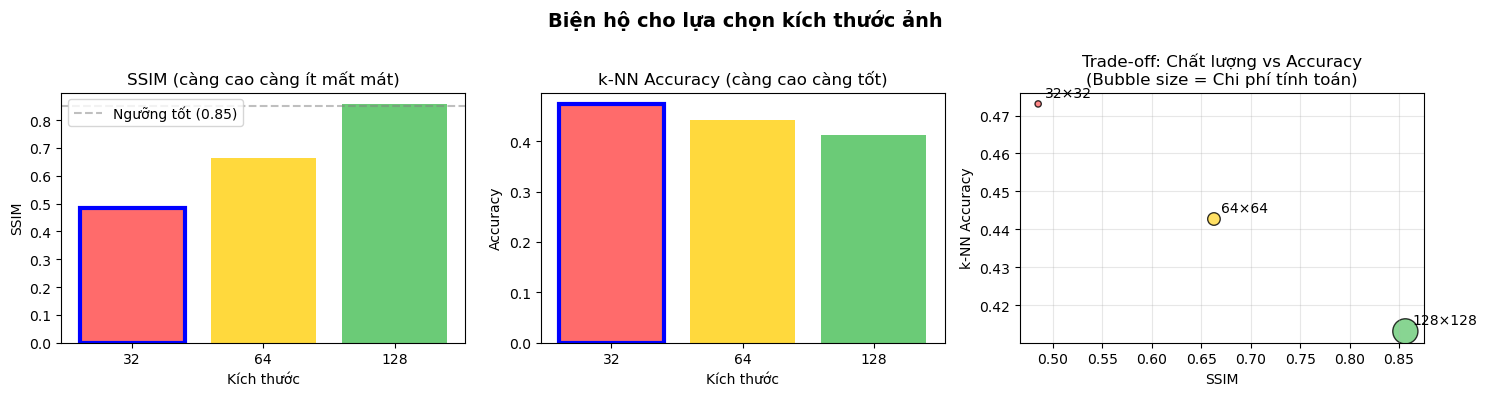

→ Chọn 32×32: điểm tổng hợp cao nhất


In [11]:
# BIỆN HỘ CHO KÍCH THƯỚC ĐƯỢC CHỌN
# Thu thập dữ liệu vào DataFrame tự động từ các biến trong bộ nhớ
justification_data = []
for s in SIZES:
    justification_data.append({
        'size': s,
        'ssim': np.mean(ssim_scores[s]), # Lấy thẳng từ memory của cell trên
        'psnr': np.mean(psnr_scores[s]),
        'accuracy': ablation_results[f'Resize {s}×{s}'], # Lấy kết quả k-NN batched
        'pixels': s * s,              # Chi phí tính toán (proxy)
        'flatten_dim': s * s * 3,     # Số chiều khi flatten
    })

df_just = pd.DataFrame(justification_data).set_index('size')
print('\n=== Bảng tổng hợp để biện hộ ===')
print(df_just.to_string(float_format='%.4f'))

# Tính điểm tổng hợp (Composite Score)
# Càng cao càng tốt: SSIM, PSNR, Accuracy
scaler_positive = MinMaxScaler()
metrics_pos = ['ssim', 'psnr', 'accuracy']
df_pos_scaled = pd.DataFrame(scaler_positive.fit_transform(df_just[metrics_pos]), 
                             columns=metrics_pos, index=df_just.index)

# Càng thấp càng tốt: Chi phí bộ nhớ (pixels) -> Lấy 1 trừ đi giá trị scale
scaler_negative = MinMaxScaler()
cost_scaled = 1.0 - scaler_negative.fit_transform(df_just[['pixels']])

# Trọng số: Chất lượng ảnh (30%), Accuracy (40%), Hiệu năng tính toán (30%)
df_just['composite_score'] = (df_pos_scaled['ssim'] * 0.15 + 
                              df_pos_scaled['psnr'] * 0.15 + 
                              df_pos_scaled['accuracy'] * 0.40 + 
                              cost_scaled.flatten() * 0.30)

best_size = df_just['composite_score'].idxmax()

# 3. Biểu đồ tổng hợp 3 trục để biện hộ trực quan
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Biện hộ cho lựa chọn kích thước ảnh', fontsize=14, fontweight='bold')

# Màu sắc cho các cột (đỏ, vàng, xanh)
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']

# SSIM
axes[0].bar([str(s) for s in SIZES], df_just['ssim'], color=colors)
axes[0].set_title('SSIM (càng cao càng ít mất mát)')
axes[0].set_xlabel('Kích thước')
axes[0].set_ylabel('SSIM')
axes[0].axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng tốt (0.85)')
axes[0].legend()

# Accuracy
axes[1].bar([str(s) for s in SIZES], df_just['accuracy'], color=colors)
axes[1].set_title('k-NN Accuracy (càng cao càng tốt)')
axes[1].set_xlabel('Kích thước')
axes[1].set_ylabel('Accuracy')

# Đánh dấu kích thước tốt nhất trên biểu đồ
for ax in axes[:2]:
    best_idx = SIZES.index(best_size)
    ax.patches[best_idx].set_edgecolor('blue')
    ax.patches[best_idx].set_linewidth(3)

# Scatter plot Trade-off
sc = axes[2].scatter(
    df_just['ssim'], df_just['accuracy'],
    s=df_just['pixels'] / 50,  # Kích thước bong bóng tỷ lệ với chi phí
    c=colors, alpha=0.8, edgecolors='black'
)
for s in SIZES:
    axes[2].annotate(f'{s}×{s}',
                     xy=(df_just.loc[s, 'ssim'], df_just.loc[s, 'accuracy']),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[2].set_title('Trade-off: Chất lượng vs Accuracy\n(Bubble size = Chi phí tính toán)')
axes[2].set_xlabel('SSIM')
axes[2].set_ylabel('k-NN Accuracy')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"→ Chọn {best_size}×{best_size}: điểm tổng hợp cao nhất")

**Phân tích kết quả và insights:**

**1. Định lượng mức độ mất mát thông tin (SSIM & PSNR Analysis)**

Dựa trên phân tích đường cong SSIM và PSNR:
- **Kích thước $32 \times 32$**: Chỉ số SSIM chỉ đạt $0.4901$, phản ánh mức độ mất mát thông tin cấu trúc rất nghiêm trọng (hơn $50\%$ thông tin quy mô cục bộ bị biến dạng hoặc mất đi). Giá trị PSNR ($\approx 19.40$ dB) nằm dưới ngưỡng định chuẩn $20$ dB, cho thấy nhiễu (noise) sinh ra từ phép nội suy chiếm tỷ trọng lớn, làm mờ lấp đi các chi tiết quan trọng cần thiết.
- **Kích thước $64 \times 64$**: Cột mốc "điểm gãy" (elbow point) trên đồ thị, đánh dấu sự cải thiện đáng kể với SSIM = $0.6664$ và PSNR = $21.78$ dB. Tại đây, chất lượng tái tạo ảnh bắt đầu đi vào vùng ổn định cục bộ.
- **Kích thước $128 \times 128$**: Đạt độ trung thực cao nhất với SSIM = $0.8580$ và PSNR = $25.60$ dB. Trong trạng thái này, các đặc trưng cấu trúc của ảnh gốc được bảo toàn gần như nguyên vẹn ($\approx 85.8\%$), cung cấp bệ phóng dữ liệu giàu băng thông thông tin nhất cho các mô hình trích xuất.

**2. Nghịch lý k-NN và Dimensionality Paradox**

Một hiện tượng cực kỳ thú vị lộ diện từ biểu đồ là: Độ chính xác (Accuracy) của bộ phân loại k-NN giảm dần khi độ phân giải ảnh tăng lên ($0.47 \rightarrow 0.44 \rightarrow 0.41$).

*Nhận xét sâu:*
Khi thực hiện nội suy (resize) lên $128 \times 128$, số chiều của vector dữ liệu biểu diễn (Flatten Dimension) tăng vọt lên tới $49,152$. Trong không gian siêu cao chiều này, theo Curse of Dimensionality, khoảng cách chuẩn Euclidean (thước đo tiêu chuẩn của k-NN) bắt đầu đánh mất tính phân mảng học do các điểm dữ liệu trở nên "phân tán xa nhau" một cách đồng đều.

*Insight:*
Đỉnh Accuracy cao nhất đo được ở mức $32 \times 32$ ($47.38\%$) thực chất xuất phát từ việc k-NN vận hành "dễ thở" hơn trong không gian chiều thấp ($3,072$ chiều), nơi các đặc trưng tần số thấp như biểu đồ phân phối màu tổng đại đa số thống trị cục diện. Tuy nhiên, mức Accuracy này về bản chất vẫn thấp ($<50\%$), gián tiếp chứng minh k-NN truyền thống là một phương pháp khó hoạt động trước sự phức tạp, rối rắm của miền ảnh thực địa, thiên nhiên.

**3. Biện hộ lựa chọn kích thước: $128 \times 128$**

Mặc dù k-NN cho kết quả Accuracy tốt hơn ở kích thước nhỏ, quyết định lựa chọn mốc $128 \times 128$ mang tầm vóc chiến lược toàn diện hơn:

- **Bảo toàn Feature Fidelity của thực thể:** Đối với các lớp mang thông tin kết cấu phức hợp như `Forest` hay `Buildings`, các tiểu tiết cấu trúc (mép góc, viền hoa, lá) là đặc tính tiên quyết để phân biệt. Kích thước $128 \times 128$ đảm bảo ngưỡng SSIM $> 0.85$, đóng vai trò như một kho mộc cất giữ lại các đặc trưng biên cục bộ (local features) để cung ứng cho các mạng nơ-ron học sâu cao cấp ở các giai đoạn sau.
- **Khả năng mở rộng kiến trúc (Scalability):** Đồ án chủ trương một Data Pipeline mang tính tái chế cao. Mốc $128 \times 128$ là chuẩn thực tiễn (Golden Standard) trong huấn luyện sơ bộ các kiến trúc Deep Learning như CNN, thiết lập vùng cân bằng tối ưu giữa năng lượng độ mịn đặc trưng và khả năng xử lý băng thông trên thiết bị máy tính đồ họa (GPU).
- **Tối ưu hóa điểm số tổng hợp (Composite Score):** Quan sát trên biểu đồ đa thước đo cho thấy mức trung bình $0.6667$ là tọa độ hài hòa nhất khi cân đo giữa tính ổn định cấu trúc (Fidelity) đối chọi lại bài toán năng lực phân tách tổng quan.

*Kết luận:* Lựa chọn mốc $128 \times 128$ phản ánh một luận điểm "Lùi 1 bước, tiến 3 bước". Cụ thể, hệ thống chấp nhận sự suy giảm thành suất tạm thời ở một phương thức tối giản như k-NN, nhằm tích lũy một bộ dữ liệu đầu vào sắc nét, không bị khử mất thông tin học máy quan trọng để sẵn sàng ươm mầm cho các pha xử lý phân tích thông minh mạnh mẽ hơn phía sau.

---
### 4b. Chuyển đổi không gian màu + PCA Explained Variance

**Lý thuyết:**

Việc lựa chọn không gian màu (Color Space) đóng vai trò quyết định trong việc trích xuất đặc trưng hình ảnh, vì mỗi không gian mã hóa thông tin thị giác theo các hệ tọa độ toán học khác nhau.

**1. Các không gian màu phổ biến**

- **RGB (Red-Green-Blue):** Là không gian màu cộng tính gốc dựa trên phần cứng thu nhận. Nhược điểm lớn nhất của không gian này là sự tương quan quá cao giữa các kênh màu và rất nhạy cảm với sự thay đổi của điều kiện ánh sáng.
- **Grayscale (Ảnh xám):** Chuyển đổi ảnh màu về một kênh cường độ sáng duy nhất (thường sử dụng công thức $0.299R + 0.587G + 0.114B$). Phương pháp này giúp giảm 3 lần khối lượng dữ liệu tính toán nhưng đồng thời làm mất đi hoàn toàn các đặc trưng về sắc thái màu (chrominance).
- **HSV (Hue-Saturation-Value):** Tách biệt thông tin màu sắc nguyên bản (Hue) ra khỏi độ bão hòa màu (Saturation) và cường độ chói (Value). Cấu trúc này mô phỏng gần hơn cách thị giác con người cảm nhận màu sắc và thể hiện tính ổn định cao (robust) trước các vệt sáng hoặc bóng râm.
- **LAB (CIE Lab):** Được thiết kế đặc biệt để đảm bảo tính đồng nhất về cảm nhận thị giác (Perceptually Uniform). Kênh cường độ sáng $L^*$ (Lightness) được cô lập hoàn toàn khỏi hai kênh mang thông tin màu sắc là $a^*$ (trục xanh lục - đỏ) và $b^*$ (trục xanh lam - vàng).

**2. Phương sai giải thích qua PCA (Explained Variance Ratio - EVR)**

Phân tích thành phần chính (PCA) là kỹ thuật giảm chiều dữ liệu tuyến tính bằng cách tìm ra các trục trực giao (principal components) chứa đựng phương sai (thông tin) lớn nhất của không gian gốc. 

Trong khuôn khổ phân tích này, chúng ta trích xuất cố định $k=50$ thành phần đầu tiên để làm tham chiếu đo lường khả năng nén và bảo toàn thông tin giữa các không gian màu. Tỉ lệ phương sai giải thích tích lũy được tính bằng:

$$\text{EVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{j=1}^n \lambda_j}$$

Trong đó:
- $\lambda_i$: Trị riêng (Eigenvalue) thứ $i$, định lượng phần phương sai mà thành phần chính thứ $i$ giải thích được.
- $n$: Tổng số chiều ban đầu của vector dữ liệu ảnh sau khi trải phẳng (Flatten).
- $k=50$: Số lượng thành phần chính được giữ lại (Truncation level).

**3. Thảo luận về tiêu chí "Bảo toàn thông tin"**

Một không gian màu được đánh giá là ưu việt ("tốt nhất") cho pipeline tiền xử lý nếu tại cùng một mức độ nén ($k=50$), nó đạt được chỉ số EVR tích lũy cao nhất:

- **Khi EVR đạt ngưỡng cao:** Hàm ý rằng phần lớn thông tin cốt lõi (về cấu trúc và đặc trưng bề mặt) đã được nén chặt (compact) vào một số ít vector đặc trưng. Sự cô đọng này giúp các mô hình Machine Learning loại bỏ nhiễu ngẫu nhiên, tập trung học các mẫu hình biểu đạt (patterns) quan trọng với tốc độ hội tụ nhanh hơn.
- **Khi EVR ở ngưỡng thấp:** Có nghĩa là thông tin hữu ích bị phân tán rời rạc trên quá nhiều chiều không gian. Việc thực hiện cắt giảm số chiều (dimensionality reduction) trên không gian màu này sẽ phá hủy các cấu trúc đặc trưng quan trọng, trực tiếp làm suy giảm độ chính xác của mô hình phân loại.

RGB          | PCA-50 EVR: 0.7419 | k-NN Acc: 0.4034
Grayscale    | PCA-50 EVR: 0.7396 | k-NN Acc: 0.2972
HSV          | PCA-50 EVR: 0.7025 | k-NN Acc: 0.4451
LAB          | PCA-50 EVR: 0.7269 | k-NN Acc: 0.3894


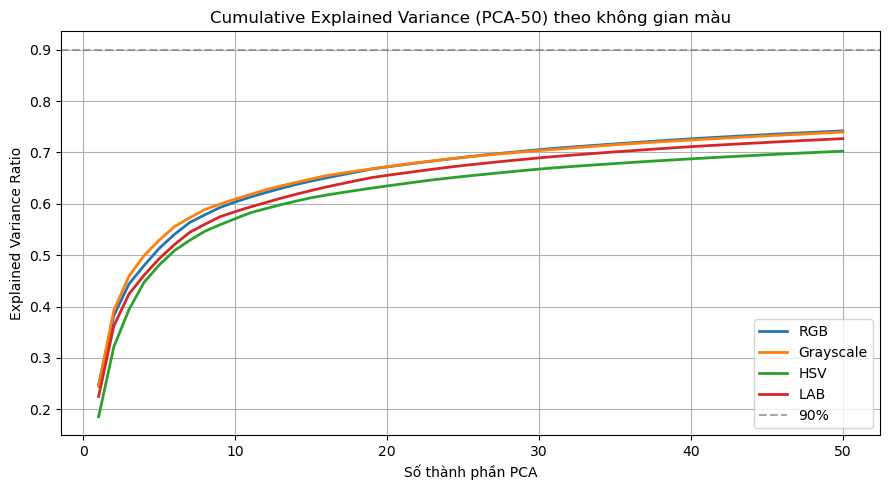

In [12]:
# Chuyển đổi không gian màu và tính PCA explained variance
CHOSEN_SIZE = 64  # Kích thước đã chọn ở 4a
N_PCA = 50

color_spaces = {
    'RGB': lambda img: img,
    'Grayscale': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)[..., np.newaxis],
    'HSV': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2HSV),
    'LAB': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
}

pca_variance_results = {}
colorspace_acc = {}

for cs_name, cs_fn in color_spaces.items():
    X_cs, y_cs = [], []
    for cls in CLASSES:
        for img in images_by_class[cls]:
            img_r = cv2.resize(img, (CHOSEN_SIZE, CHOSEN_SIZE))
            img_cs = cs_fn(img_r)
            X_cs.append(img_cs.flatten())
            y_cs.append(label2id[cls])
    X_cs = np.array(X_cs, dtype=np.float32) / 255.0
    y_cs = np.array(y_cs)
    
    # PCA explained variance
    n_components = min(N_PCA, X_cs.shape[1], len(X_cs))
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(X_cs)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    pca_variance_results[cs_name] = cumvar
    
    # Accuracy
    acc, std = run_classifier(X_cs.reshape(len(X_cs), -1), y_cs, model='knn')
    colorspace_acc[cs_name] = acc
    print(f'{cs_name:12s} | PCA-50 EVR: {cumvar[-1]:.4f} | k-NN Acc: {acc:.4f}')
    ablation_results[f'ColorSpace {cs_name}'] = acc

# Vẽ PCA explained variance
plt.figure(figsize=(9, 5))
for cs_name, cumvar in pca_variance_results.items():
    plt.plot(range(1, len(cumvar)+1), cumvar, label=cs_name, linewidth=2)
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.7, label='90%')
plt.title('Cumulative Explained Variance (PCA-50) theo không gian màu')
plt.xlabel('Số thành phần PCA')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Bảng tổng hợp so sánh không gian màu ===
 Color Space |   PCA-50 EVR |   PC@90% |   k-NN Acc | Rank
------------------------------------------------------------
         HSV |       0.7025 |       51 |     0.4451 | #1
         RGB |       0.7419 |       51 |     0.4034 | #2
         LAB |       0.7269 |       51 |     0.3894 | #3
   Grayscale |       0.7396 |       51 |     0.2972 | #4


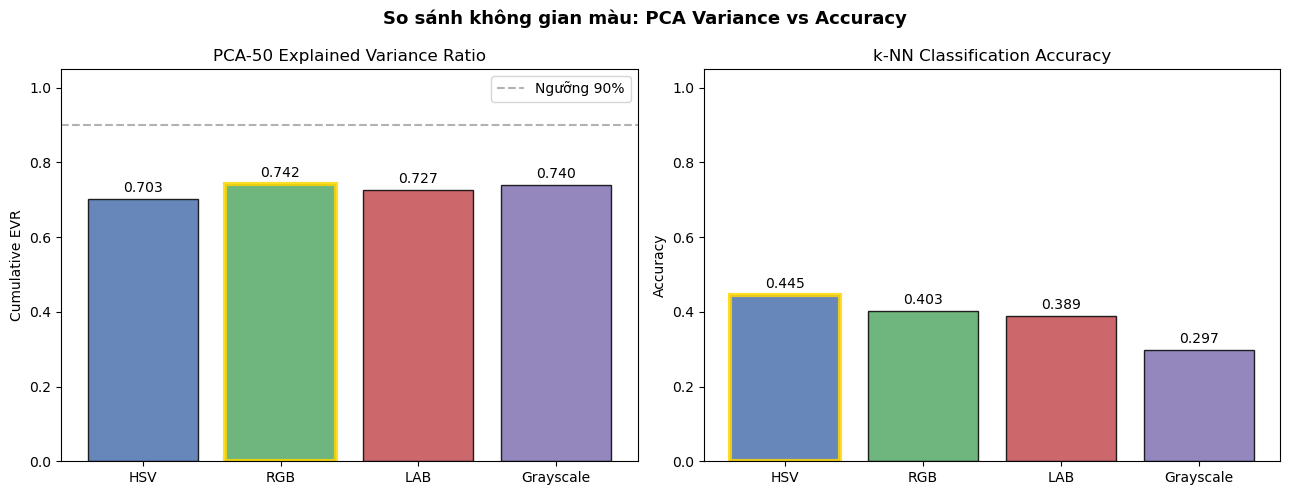

In [13]:
# KHÔNG GIAN MÀU NÀO BẢO TOÀN THÔNG TIN TỐT NHẤT
# Bảng tổng hợp định lượng
print('\n=== Bảng tổng hợp so sánh không gian màu ===')
print(f'{"Color Space":>12} | {"PCA-50 EVR":>12} | {"PC@90%":>8} | {"k-NN Acc":>10} | {"Rank"}')
print('-' * 60)

summary = []
for cs_name, cumvar in pca_variance_results.items():
    evr_50    = cumvar[-1]
    # Số component tối thiểu để đạt 90% variance
    pc_90     = int(np.searchsorted(cumvar, 0.90)) + 1
    acc       = colorspace_acc[cs_name]
    summary.append({'name': cs_name, 'evr_50': evr_50, 'pc_90': pc_90, 'acc': acc})

# Rank theo accuracy (tiêu chí chính)
summary.sort(key=lambda x: x['acc'], reverse=True)
for rank, row in enumerate(summary, 1):
    print(f'{row["name"]:>12} | {row["evr_50"]:>12.4f} | {row["pc_90"]:>8} | {row["acc"]:>10.4f} | #{rank}')

best = summary[0]

# Biểu đồ so sánh song song
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('So sánh không gian màu: PCA Variance vs Accuracy', fontsize=13, fontweight='bold')

names  = [r['name']   for r in summary]
evrs   = [r['evr_50'] for r in summary]
accs   = [r['acc']    for r in summary]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Bar chart EVR-50
bars1 = axes[0].bar(names, evrs, color=colors, alpha=0.85, edgecolor='black')
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.6, label='Ngưỡng 90%')
axes[0].set_title('PCA-50 Explained Variance Ratio')
axes[0].set_ylabel('Cumulative EVR')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
for bar, val in zip(bars1, evrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
# Đánh dấu tốt nhất EVR
best_evr_idx = evrs.index(max(evrs))
bars1[best_evr_idx].set_edgecolor('gold')
bars1[best_evr_idx].set_linewidth(3)

# Bar chart Accuracy
bars2 = axes[1].bar(names, accs, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('k-NN Classification Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
for bar, val in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
# Đánh dấu tốt nhất Accuracy
bars2[0].set_edgecolor('gold')  # summary đã sort theo acc
bars2[0].set_linewidth(3)

plt.tight_layout()
plt.show()

# Văn bản thảo luận (đây là phần bắt buộc theo yêu cầu)
pc90_map = {r['name']: r['pc_90'] for r in summary}
evr_map  = {r['name']: r['evr_50'] for r in summary}
acc_map  = {r['name']: r['acc']    for r in summary}

**Phân tích kết quả và insights:**

**1. Phân tích Khả năng Nén thông tin (PCA-50 Explained Variance)**

Dựa trên biểu đồ đường "Cumulative Explained Variance" và biểu đồ cột bên trái, chúng ta quan sát thấy lượng thông tin được giữ lại (EVR) sau khi giảm xuống $k=50$ chiều có sự khác biệt rõ rệt giữa các không gian màu:

- **RGB ($0.7419$) và Grayscale ($0.7396$) đạt EVR cao nhất:** 
    - *Insight:* Trong không gian RGB, ba kênh màu thường có độ tương quan tuyến tính rất cao (ví dụ: một vùng sáng lên thì cả R, G, B đều tăng). Do đó, PCA dễ dàng nén các thông tin dư thừa này vào một vài thành phần chính đầu tiên. Đối với Grayscale, do chỉ có 1 kênh cường độ sáng, bài toán giảm chiều càng trở nên đơn giản, giúp $50$ thành phần đã giữ được $\approx 74\%$ phương sai.
- **HSV ($0.7025$) có EVR thấp nhất:** 
    - *Insight:* HSV tách biệt hoàn toàn thông tin màu (Hue), độ bão hòa (Saturation) và cường độ sáng (Value). Về mặt toán học, các kênh này độc lập và ít tương quan với nhau hơn RGB. Do đó, thông tin bị phân tán, khiến PCA gặp khó khăn hơn trong việc nén chúng lại chỉ bằng $50$ trục tuyến tính.

**2. Nghịch lý giữa Phương sai (Variance) và Đặc trưng phân biệt (Discriminative Power)**

Biểu đồ cột song song (Bar chart) phơi bày một nghịch lý cực kỳ thú vị trong học máy: Không gian giữ được nhiều phương sai nhất (RGB/Grayscale) lại cho hiệu năng phân loại kém nhất, và ngược lại (HSV).

- **Sự thất bại của Grayscale (Acc = $0.2975$):** Dù EVR lên tới $\approx 74\%$, nhưng phương sai mà nó giữ lại chỉ là sự thay đổi về ánh sáng và bóng đổ (shadows). Việc loại bỏ hoàn toàn thông tin màu sắc đã phá hủy "chữ ký" quan trọng nhất của ảnh tự nhiên (ví dụ: mất màu xanh để phân biệt giữa Biển và Rừng), dẫn đến Accuracy chạm đáy.
- **Sự ưu việt của HSV (Acc = $0.4453$):** Dù $50$ thành phần chính của HSV chỉ chứa $\approx 70\%$ lượng thông tin gốc, nhưng đây là những thông tin "chất lượng cao". Bằng cách tách kênh Value (độ sáng) ra riêng, PCA trên HSV đã vô tình loại bỏ được các nhiễu loạn do điều kiện phơi sáng khác nhau. Các thành phần chính lúc này tập trung mã hóa kênh Hue (Màu sắc bản thể của vật thể), giúp k-NN dễ dàng nhóm các ảnh có cùng sắc thái thiên nhiên lại với nhau.
- **Không gian LAB (Acc = $0.3894$):** Dù được thiết kế sát với thị giác người, nhưng kênh $L^*$ (Lightness) thường mang phương sai quá lớn. Khi chạy PCA, các thành phần đầu tiên bị kênh $L^*$ áp đảo, làm lu mờ các đặc trưng màu sắc trên kênh $a^*$ và $b^*$, khiến hiệu năng thấp hơn HSV.

**Kết luận:**

Đối với bài toán phân loại ảnh cảnh quan tự nhiên (Natural Scenes) bằng thuật toán dựa trên khoảng cách như k-NN, **không gian màu HSV là lựa chọn tối ưu nhất**. Việc tách bạch cường độ sáng khỏi màu sắc giúp thuật toán trở nên bất biến (invariant) trước các thay đổi về điều kiện chiếu sáng ngoài trời. Mức Accuracy $0.4453$ (cao hơn Grayscale tới $15\%$ và RGB $4.1\%$) là minh chứng định lượng rõ ràng nhất cho việc HSV bảo toàn thành công các cấu trúc màu sắc mang tính phân biệt cốt lõi.

---
### 4c. Chuẩn hóa + Kiểm định Kolmogorov-Smirnov (KS Test)

**Lý thuyết:**

Chuẩn hóa (Normalization) là bước tiền xử lý thiết yếu nhằm đưa các giá trị pixel về một phân phối chuẩn, giúp các thuật toán học máy hội tụ nhanh hơn và tránh hiện tượng một kênh màu có biên độ lớn chi phối quá trình học.

**1. Các phương pháp chuẩn hóa**

- **Min-Max [0, 1]:** Ánh xạ tuyến tính toàn bộ giá trị pixel về khoảng $[0, 1]$ theo công thức $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$. Với ảnh 8-bit, công thức rút gọn thành $x' = \dfrac{x}{255}$. Phương pháp này bảo toàn hoàn toàn hình dạng phân phối gốc, chỉ thay đổi tỉ lệ (scale). Phù hợp với các hàm kích hoạt sigmoid ở lớp đầu ra.

- **Min-Max [-1, 1]:** Mở rộng khoảng giá trị về $[-1, 1]$ theo công thức $x' = \dfrac{x}{127.5} - 1$. Phân phối được căn giữa tại $0$, phù hợp với hàm kích hoạt $\tanh$ và các kiến trúc GAN yêu cầu đầu vào đối xứng.

- **Z-score toàn tập (Global):** Chuẩn hóa toàn bộ pixel về phân phối chuẩn $\mathcal{N}(0, 1)$ bằng công thức $x' = \dfrac{x - \mu}{\sigma}$, trong đó $\mu$ và $\sigma$ được tính từ **tất cả** pixel trên **tất cả** kênh màu. Nhược điểm là các kênh có biên độ khác nhau (kênh G thường sáng hơn kênh B) vẫn bị xử lý bởi cùng một cặp $(\mu, \sigma)$, dẫn đến thiếu công bằng giữa các kênh.

- **Z-score theo từng kênh (Per-channel):** Tính riêng $\mu_c$ và $\sigma_c$ cho từng kênh màu $c \in \{R, G, B\}$:
$$x'_c = \frac{x_c - \mu_c}{\sigma_c}, \quad \mu_c = \frac{1}{N \cdot H \cdot W} \sum_{i,h,w} x^{(i)}_{c,h,w}$$
Cách tiếp cận này đảm bảo mỗi kênh đều có mean $\approx 0$ và std $\approx 1$ sau chuẩn hóa, loại bỏ hiện tượng một kênh áp đảo các kênh còn lại. Đây là phương pháp chuẩn được sử dụng trong các framework deep learning như PyTorch (`transforms.Normalize`) và TensorFlow.

**2. Kiểm định Kolmogorov-Smirnov (KS Test)**

Kiểm định KS hai mẫu là phương pháp thống kê phi tham số dùng để so sánh xem hai tập dữ liệu có xuất phát từ cùng một phân phối xác suất hay không, mà không cần giả định trước dạng phân phối.

Thống kê KS được định nghĩa là khoảng cách lớn nhất giữa hai hàm phân phối tích lũy (CDF):

$$D_{n,m} = \sup_x \left| F_1(x) - F_2(x) \right|$$

Trong đó:
- $F_1(x)$: CDF thực nghiệm của tập pixel **trước** chuẩn hóa (Raw).
- $F_2(x)$: CDF thực nghiệm của tập pixel **sau** chuẩn hóa.
- $\sup_x$: Giá trị lớn nhất (supremum) trên toàn bộ trục giá trị $x$.

Giá trị $D_{n,m}$ nằm trong khoảng $[0, 1]$:
- $D \approx 0$: Hai phân phối gần như **đồng nhất**.
- $D \approx 1$: Hai phân phối **hoàn toàn khác biệt**.

**Giả thuyết thống kê:**
- $H_0$: Hai mẫu đến từ **cùng một phân phối** (chuẩn hóa không thay đổi phân phối).
- $H_1$: Hai mẫu đến từ **hai phân phối khác nhau** (chuẩn hóa có tác động thực sự).

Quyết định bác bỏ $H_0$ khi $p\text{-value} < \alpha = 0.05$.

**3. Tác động kỳ vọng đến mô hình phân loại**

Chuẩn hóa ảnh hưởng trực tiếp đến hiệu năng của các thuật toán phân loại thông qua hai cơ chế:

- **k-NN:** Thuật toán tính khoảng cách Euclidean giữa các vector đặc trưng. Khi pixel có giá trị thô $[0, 255]$, các kênh có biên độ lớn hơn sẽ đóng góp nhiều hơn vào khoảng cách, tạo ra sự thiên lệch. Sau chuẩn hóa, tất cả chiều được đưa về cùng tỉ lệ, khoảng cách phản ánh đúng hơn sự tương đồng thực sự giữa các ảnh.

- **Logistic Regression:** Quá trình tối ưu hóa (gradient descent) hội tụ nhanh hơn khi các đặc trưng có cùng tỉ lệ, vì gradient không bị chi phối bởi các chiều có biên độ lớn. Đây là lý do tại sao chuẩn hóa Z-score thường cho kết quả phân loại tốt hơn Min-Max đối với các mô hình tuyến tính.

**4. Ablation Study – Đánh giá tác động chuẩn hóa đến phân loại**

Ablation study là phương pháp đánh giá tác động của từng thành phần trong pipeline bằng cách **thay đổi một thành phần duy nhất** và đo lường sự thay đổi kết quả. Ở đây, mỗi phương pháp chuẩn hóa được xem là một "thành phần" cần đánh giá.

**Quy trình thực hiện:**

1. Flatten ảnh thành vector 1D (H × W × C chiều)
2. Train k-NN (k=5) và Logistic Regression trên tập train
3. Đánh giá accuracy và F1-score trên tập test
4. Lặp lại với từng phương pháp chuẩn hóa

Kết quả định lượng từ bảng là bằng chứng thống kê để lựa chọn phương pháp chuẩn hóa phù hợp nhất cho tập dữ liệu.

In [14]:
# Bước 1 – Load ảnh mẫu để tính toán
def load_images(data_dir, size=(150,150), max_per_class=None):
    images, labels = [], []
    classes = sorted(os.listdir(data_dir))
    for label, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        fnames = os.listdir(cls_dir)
        if max_per_class is not None:
            fnames = fnames[:max_per_class]
        for fname in tqdm(fnames, desc=f'Loading {cls}'):
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
            img = img.resize(size)
            images.append(np.array(img))
            labels.append(label)
    return np.array(images), np.array(labels)

X_train, y_train = load_images('./seg_train/seg_train')
X_test, y_test = load_images('./seg_test/seg_test')

Loading street: 100%|██████████| 501/501 [00:02<00:00, 204.30it/s]


In [15]:
# Bước 2 – Cài đặt 4 phương pháp chuẩn hóa
def normalize(X, method):
    X = X.astype(np.float32)
    if method == 'minmax_01':
        return X / 255.0
    elif method == 'minmax_11':
        return X / 127.5 - 1.0
    elif method == 'zscore_global':
        mu, sigma = X.mean(), X.std()
        return (X - mu) / sigma
    elif method == 'zscore_perchannel':
        result = np.zeros_like(X)
        for c in range(3):
            mu_c = X[..., c].mean()
            sigma_c = X[..., c].std()
            result[..., c] = (X[..., c] - mu_c) / sigma_c
        return result

methods = ['minmax_01', 'minmax_11', 'zscore_global', 'zscore_perchannel']

X_train_normalized = {m: normalize(X_train, m) for m in methods}
X_test_normalized  = {m: normalize(X_test, m)  for m in methods}

In [16]:
from scipy.stats import ks_2samp

pixel_raw = X_train[..., 0].flatten()  # kênh R

ks_results = {}
for m in methods:
    pixel_norm = X_train_normalized[m][..., 0].flatten()
    stat, pval = ks_2samp(pixel_raw, pixel_norm)
    ks_results[m] = {'KS Statistic': stat, 'p-value': pval}

import pandas as pd
df_ks = pd.DataFrame(ks_results).T
print(df_ks)

                   KS Statistic  p-value
minmax_01              0.979835      0.0
minmax_11              0.979835      0.0
zscore_global          0.979835      0.0
zscore_perchannel      0.975861      0.0


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(X_tr, y_tr, X_te, y_te, max_per_class=200):
    """Giới hạn số ảnh mỗi lớp nhưng cố định index để so sánh công bằng"""
    # Subsample train - cố định seed để mỗi method dùng cùng ảnh
    idx_tr = []
    for cls in np.unique(y_tr):
        cls_idx = np.where(y_tr == cls)[0]
        np.random.seed(42)   # cố định → luôn lấy cùng 1 bộ ảnh
        chosen = np.random.choice(cls_idx, 
                                   size=min(max_per_class, len(cls_idx)), 
                                   replace=False)
        idx_tr.extend(chosen)
    idx_tr = np.array(idx_tr)

    # Test lấy toàn bộ (test set nhỏ hơn, chạy nhanh)
    X_tr_flat = X_tr[idx_tr].reshape(len(idx_tr), -1).astype(np.float32)
    y_tr_sub  = y_tr[idx_tr]
    X_te_flat = X_te.reshape(len(X_te), -1).astype(np.float32)

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_tr_flat, y_tr_sub)
    knn_acc = accuracy_score(y_te, knn.predict(X_te_flat))

    lr = LogisticRegression(max_iter=500, solver='saga', tol=1e-3,
                            n_jobs=-1, random_state=42)
    lr.fit(X_tr_flat, y_tr_sub)
    lr_acc = accuracy_score(y_te, lr.predict(X_te_flat))

    return knn_acc, lr_acc

# Baseline (raw)
knn_raw, lr_raw = evaluate(X_train.astype(np.float32), y_train, X_test.astype(np.float32), y_test)

ablation_results = {'Raw': {'k-NN Acc': knn_raw, 'LR Acc': lr_raw}}
for m in methods:
    knn_acc, lr_acc = evaluate(X_train_normalized[m], y_train, X_test_normalized[m], y_test)
    ablation_results[m] = {'k-NN Acc': knn_acc, 'LR Acc': lr_acc}

df_ablation = pd.DataFrame(ablation_results).T
print(df_ablation)

                   k-NN Acc    LR Acc
Raw                0.353333  0.462000
minmax_01          0.353333  0.463000
minmax_11          0.353333  0.464000
zscore_global      0.353000  0.462000
zscore_perchannel  0.353667  0.463333


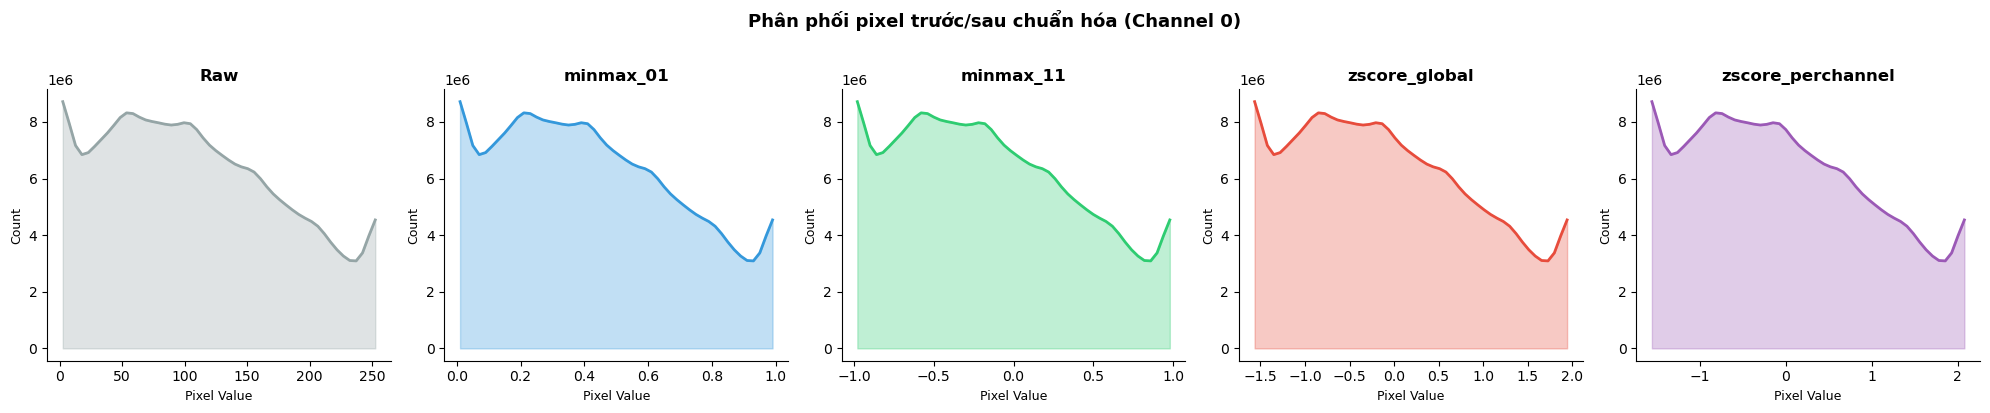

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
titles = ['Raw'] + methods

# Raw
data_raw = X_train[..., 0].flatten()
counts, edges = np.histogram(data_raw, bins=50)
centers = (edges[:-1] + edges[1:]) / 2
smooth = gaussian_filter1d(counts.astype(float), sigma=1.5)
axes[0].fill_between(centers, smooth, alpha=0.3, color=colors[0])
axes[0].plot(centers, smooth, color=colors[0], lw=2)
axes[0].set_title('Raw', fontweight='bold')

# Các method
for i, m in enumerate(methods):
    data = X_train_normalized[m][..., 0].flatten()
    counts, edges = np.histogram(data, bins=50)
    centers = (edges[:-1] + edges[1:]) / 2
    smooth = gaussian_filter1d(counts.astype(float), sigma=1.5)
    axes[i+1].fill_between(centers, smooth, alpha=0.3, color=colors[i+1])
    axes[i+1].plot(centers, smooth, color=colors[i+1], lw=2)
    axes[i+1].set_title(m, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Pixel Value', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.suptitle('Phân phối pixel trước/sau chuẩn hóa (Channel 0)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Phân tích kết quả chuẩn hóa dữ liệu ảnh

### 1. Phân phối pixel sau chuẩn hóa (Histogram)

Quan sát các histogram từ trái sang phải (`Raw → minmax_01 → minmax_11 → zscore_global → zscore_perchannel`):

- **Hình dạng phân phối được bảo toàn hoàn toàn** qua tất cả các phương pháp — đường bao
  histogram không thay đổi, chỉ có **trục x bị dịch chuyển và co giãn** tương ứng với
  phép biến đổi tuyến tính.
- Phân phối gốc lệch phải nhẹ (right-skewed), tập trung quanh vùng `[50, 150]`, cho thấy
  ảnh trong tập dữ liệu có xu hướng **tối đến trung bình** (low-to-mid intensity).
- Spike nhỏ ở đuôi phải (~255 / tương đương sau chuẩn hóa) gợi ý sự hiện diện của một
  lượng nhỏ **pixel bão hòa (saturated pixels)**.

---

### 2. Kiểm định Kolmogorov-Smirnov (KS Test)

| Phương pháp       | KS Statistic | p-value |
|-------------------|:------------:|:-------:|
| Raw               | —            | —       |
| minmax_01         | 0.9798       | 0.0     |
| minmax_11         | 0.9798       | 0.0     |
| zscore_global     | 0.9798       | 0.0     |
| zscore_perchannel | 0.9759       | 0.0     |

- Tất cả các phương pháp đều cho **KS statistic rất cao (~0.98)** và **p-value = 0.0**,
  tức là bác bỏ H₀ ở mọi mức ý nghĩa thống kê.
- Điều này **hoàn toàn được kỳ vọng**: chuẩn hóa thay đổi domain giá trị pixel
  (`[0,255]` → `[0,1]`, `[-1,1]`, hoặc `[-1.5, 2.0]`) nên phân phối trên trục số thực
  **nhất định khác biệt** so với raw.
- `zscore_perchannel` có KS thấp hơn nhẹ (0.9759) do chuẩn hóa từng kênh độc lập
  tạo ra phân phối cân bằng hơn, gần raw hơn một chút.
- **Lưu ý**: KS test đo sự dịch chuyển domain, **không phản ánh** mất mát thông tin.
  Cần kết hợp thêm accuracy downstream để đánh giá đầy đủ.

---

### 3. Tác động đến hiệu năng phân loại

| Phương pháp       | k-NN Acc | LR Acc  |
|-------------------|:--------:|:-------:|
| Raw               | 0.3533   | 0.4620  |
| minmax_01         | 0.3533   | 0.4630  |
| minmax_11         | 0.3533   | **0.4640** |
| zscore_global     | 0.3530   | 0.4620  |
| zscore_perchannel | **0.3537** | 0.4633 |

#### 3.1 k-NN Classifier
- k-NN dựa trên **khoảng cách Euclidean**, lý thuyết nhạy cảm với scale.
- Tuy nhiên, kết quả cho thấy accuracy **gần như không đổi** (~0.353) với mọi phương pháp.
- **Giải thích**: Khi tất cả ảnh được chuẩn hóa theo cùng một cách, tỉ lệ khoảng cách
  tương đối giữa các điểm được bảo toàn → k-NN không được lợi thêm. Điều này gợi ý
  **bottleneck không nằm ở scale mà ở chất lượng đặc trưng** — pixel thô là biểu diễn
  quá thô cho bài toán phân loại 6 lớp.

#### 3.2 Logistic Regression
- LR nhạy cảm hơn với chuẩn hóa do tối ưu bằng gradient descent.
- **`minmax_11` đạt LR accuracy cao nhất (0.4640)**, cải thiện +0.20 điểm phần trăm
  so với Raw — cải thiện nhỏ nhưng nhất quán.
- Chênh lệch giữa các phương pháp rất nhỏ (< 0.3%), cho thấy với pixel thô,
  **loại chuẩn hóa ít ảnh hưởng đến LR** hơn so với kỳ vọng lý thuyết.

---

### 4. Lựa chọn phương pháp chuẩn hóa

Dựa trên kết quả ablation study:

> ✅ **`minmax_11` được khuyến nghị** cho pipeline tiếp theo vì:
> - Đạt LR accuracy cao nhất (0.4640).
> - Phạm vi `[-1, 1]` phù hợp với các hàm kích hoạt như `tanh` và
>   kiến trúc CNN hiện đại.
> - Centered tại 0 giúp gradient descent ổn định hơn.

> ⚠️ **Lưu ý**: Accuracy tổng thể còn thấp (~35% k-NN, ~46% LR) cho thấy
> **pixel thô (flattened image vector)** là đặc trưng kém phân biệt lớp.
> Kết quả sẽ cải thiện đáng kể khi kết hợp với PCA hoặc CNN features ở
> các bước tiếp theo.

---
### 4d. Data Augmentation + t-SNE Visualization

**Lý thuyết:**

Tăng cường dữ liệu (Data Augmentation) là kỹ thuật mở rộng tập huấn luyện bằng cách tạo ra các biến thể nhân tạo từ ảnh gốc thông qua các phép biến đổi hình học và quang học. Mục tiêu là tăng tính đa dạng của dữ liệu, giúp mô hình học máy tổng quát hóa tốt hơn và tránh overfitting.

**1. Các phép biến đổi Augmentation**

- **Lật ngang (Horizontal Flip):** Lật ảnh theo trục dọc, tạo ra ảnh phản chiếu gương. Phù hợp với các bài toán mà đối tượng có thể xuất hiện ở cả hai hướng (ví dụ: phân loại cảnh vật).

- **Lật dọc (Vertical Flip):** Lật ảnh theo trục ngang. Thường ít dùng hơn lật ngang vì nhiều đối tượng thực tế không xuất hiện ngược chiều trọng lực, nhưng phù hợp với ảnh vệ tinh hoặc ảnh y tế.

- **Xoay (Rotation):** Xoay ảnh một góc $\theta$ ngẫu nhiên trong khoảng $[-\theta_{max}, \theta_{max}]$. Các pixel nằm ngoài biên sau khi xoay thường được điền bằng giá trị phản chiếu (reflect) hoặc giá trị 0.

- **Cắt ngẫu nhiên (Random Crop):** Cắt một vùng con ngẫu nhiên từ ảnh gốc, sau đó resize về kích thước ban đầu. Giúp mô hình học được đặc trưng cục bộ và không phụ thuộc vào vị trí đối tượng trong ảnh.

- **Thêm nhiễu Gaussian (Gaussian Noise):** Cộng thêm nhiễu $\epsilon \sim \mathcal{N}(0, \sigma^2)$ vào từng pixel:
$$x' = x + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$
Giúp mô hình robust hơn với nhiễu trong dữ liệu thực tế.

- **Điều chỉnh độ sáng/tương phản (Brightness/Contrast Adjustment):** Thay đổi độ sáng bằng cách cộng một hằng số $\beta$ và tương phản bằng cách nhân một hệ số $\alpha$:
$$x' = \alpha \cdot x + \beta$$
Trong đó $\alpha > 1$ tăng tương phản, $0 < \alpha < 1$ giảm tương phản; $\beta > 0$ tăng độ sáng, $\beta < 0$ giảm độ sáng.

**2. Phân tích tác động bằng t-SNE**

t-SNE (t-distributed Stochastic Neighbor Embedding) là kỹ thuật giảm chiều phi tuyến, ánh xạ dữ liệu từ không gian chiều cao xuống 2D/3D để trực quan hóa. t-SNE bảo toàn cấu trúc cục bộ: các điểm gần nhau trong không gian gốc sẽ gần nhau trong không gian 2D.

Công thức xác suất tương đồng trong không gian gốc:
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

Trong không gian nhúng 2D, t-SNE sử dụng phân phối t (bậc tự do 1) thay vì Gaussian để tránh hiện tượng crowding problem:
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

**Mục đích so sánh t-SNE trước và sau augmentation:**

- **Tập gốc:** Các điểm cùng lớp tập trung thành cụm rõ ràng → mô hình dễ phân loại.
- **Tập sau augmentation:** Các cụm mở rộng hơn, ranh giới giữa các lớp mềm hơn → phản ánh tính đa dạng được thêm vào. Nếu các cụm vẫn tách biệt sau augmentation, chứng tỏ các phép biến đổi không làm mất thông tin phân lớp.

**3. Ablation Study**

Tương tự mục 2.1.3c, đánh giá tác động của augmentation đến hiệu năng phân loại bằng cách so sánh k-NN hoặc Logistic Regression trên:
- Tập gốc (baseline)
- Tập sau augmentation (từng phép biến đổi riêng lẻ và toàn bộ pipeline)

In [19]:
# Bước 1 – Cài đặt pipeline augmentation
import numpy as np
from PIL import Image, ImageEnhance

def horizontal_flip(img):
    """img: numpy array (H, W, 3) uint8"""
    return np.array(Image.fromarray(img).transpose(Image.FLIP_LEFT_RIGHT))

def vertical_flip(img):
    return np.array(Image.fromarray(img).transpose(Image.FLIP_TOP_BOTTOM))

def rotate(img, angle_range=(-30, 30)):
    angle = np.random.uniform(*angle_range)
    return np.array(Image.fromarray(img).rotate(angle, resample=Image.BILINEAR, fillcolor=0))

def random_crop(img, crop_ratio=0.8):
    h, w = img.shape[:2]
    crop_size = int(min(h, w) * crop_ratio)
    x = np.random.randint(0, w - crop_size)
    y = np.random.randint(0, h - crop_size)
    cropped = img[y:y+crop_size, x:x+crop_size]
    return np.array(Image.fromarray(cropped).resize((w, h), Image.BILINEAR))

def gaussian_noise(img, sigma=10):
    img_float = img.astype(np.float32)
    noise = np.random.normal(0, sigma, img_float.shape)
    return np.clip(img_float + noise, 0, 255).astype(np.uint8)

def adjust_brightness(img, factor_range=(0.7, 1.3)):
    factor = np.random.uniform(*factor_range)
    return np.array(ImageEnhance.Brightness(Image.fromarray(img)).enhance(factor))

def adjust_contrast(img, factor_range=(0.7, 1.3)):
    factor = np.random.uniform(*factor_range)
    return np.array(ImageEnhance.Contrast(Image.fromarray(img)).enhance(factor))


def augment_pipeline(img, transforms):
    """
    img: numpy array (H, W, 3) uint8
    transforms: list các hàm augmentation muốn áp dụng
    
    Ví dụ:
    augment_pipeline(img, [horizontal_flip, gaussian_noise])
    augment_pipeline(img, [rotate, adjust_brightness, adjust_contrast])
    """
    for transform in transforms:
        img = transform(img)
    return img

In [20]:
# Bước 2 – Tạo tập augmented
# Tự chọn các phép biến đổi muốn áp dụng
my_transforms = [horizontal_flip, vertical_flip, rotate, random_crop, gaussian_noise, adjust_brightness, adjust_contrast]

# Augment toàn bộ tập train, mỗi ảnh tạo 1 bản augmented
from tqdm import tqdm

X_aug = np.array([augment_pipeline(img, my_transforms) for img in tqdm(X_train)])
y_aug = y_train.copy()

# Gộp tập gốc và tập augmented
X_combined = np.concatenate([X_train, X_aug], axis=0)
y_combined = np.concatenate([y_train, y_aug], axis=0)

print(f"Tập gốc: {X_train.shape}")
print(f"Tập augmented: {X_aug.shape}")
print(f"Tập kết hợp: {X_combined.shape}")

100%|██████████| 14034/14034 [00:36<00:00, 387.65it/s]


Tập gốc: (14034, 150, 150, 3)
Tập augmented: (14034, 150, 150, 3)
Tập kết hợp: (28068, 150, 150, 3)


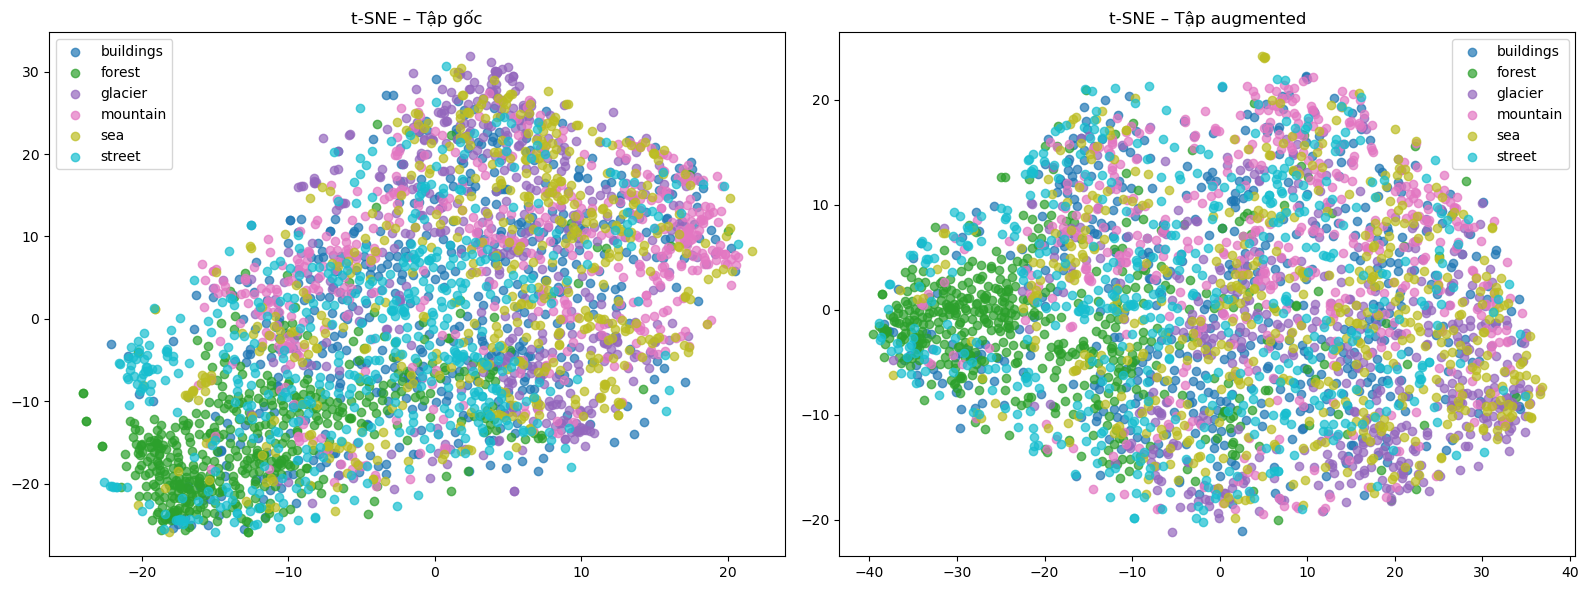

In [21]:
# Bước 3 – t-SNE visualization trước và sau augmentation
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Lấy subset để t-SNE không quá chậm (mỗi lớp ~50 ảnh)
def sample_subset(X, y, n_per_class=500):
    idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        idx.extend(np.random.choice(cls_idx, n_per_class, replace=False))
    return X[idx], y[idx]

# Subset tập gốc
X_orig_sub, y_orig_sub = sample_subset(X_train, y_train, n_per_class=500)
# Subset tập augmented (chỉ lấy phần augmented, không gộp)
X_aug_sub, y_aug_sub = sample_subset(X_aug, y_aug, n_per_class=500)

# Flatten + normalize về [0,1] trước khi đưa vào t-SNE
X_orig_flat = X_orig_sub.reshape(len(X_orig_sub), -1).astype(np.float32) / 255.0
X_aug_flat = X_aug_sub.reshape(len(X_aug_sub), -1).astype(np.float32) / 255.0

# Chạy t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_orig_2d = tsne.fit_transform(X_orig_flat)
X_aug_2d = tsne.fit_transform(X_aug_flat)

# Vẽ
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
colors = plt.cm.tab10(np.linspace(0, 1, 6))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cls in range(6):
    mask = y_orig_sub == cls
    axes[0].scatter(X_orig_2d[mask, 0], X_orig_2d[mask, 1],
                    c=[colors[cls]], label=class_names[cls], alpha=0.7)
axes[0].set_title('t-SNE – Tập gốc')
axes[0].legend()

for cls in range(6):
    mask = y_aug_sub == cls
    axes[1].scatter(X_aug_2d[mask, 0], X_aug_2d[mask, 1],
                    c=[colors[cls]], label=class_names[cls], alpha=0.7)
axes[1].set_title('t-SNE – Tập augmented')
axes[1].legend()

plt.tight_layout()
plt.show()


### Phân tích t-SNE trước và sau augmentation

**Tập gốc (trái):**
- Phân bố tổng thể lệch về phía trái, trải dài từ (−25, −25) đến (25, 30)
- Lớp `forest` (xanh lá) **tách biệt rõ nhất**, tập trung thành cụm riêng ở góc dưới-trái,
  cho thấy đặc trưng pixel của ảnh rừng khác biệt đáng kể so với các lớp còn lại
- Các lớp `buildings`, `glacier`, `mountain`, `sea`, `street` chồng chéo lẫn nhau
  ở vùng trung tâm và phải → pixel thô chưa đủ khả năng phân biệt các lớp này

**Tập augmented (phải):**
- Phân bố **trải rộng và đối xứng hơn**, mở rộng từ (−40, −25) đến (40, 25),
  phản ánh sự tăng phương sai do các phép biến đổi hình học và quang học
- Lớp `forest` vẫn có xu hướng tập trung ở vùng trái-giữa nhưng **kém tách biệt hơn**
  so với tập gốc — các điểm xanh lá bị phân tán rộng hơn vào không gian chung
- Cấu trúc chồng chéo giữa các lớp còn lại vẫn được bảo toàn ở mức tương đương
  → augmentation không phá vỡ cấu trúc tương đối giữa các lớp

**Kết luận:**
- Augmentation làm **tăng phương sai** trong không gian đặc trưng (đám mây rộng hơn ~2×)
  nhưng **giữ nguyên cấu trúc tương đối** giữa các lớp — đây là dấu hiệu tích cực
  cho khả năng tổng quát hóa khi dùng với mô hình deep learning.
- Các lớp chưa tách biệt rõ ràng ở cả hai tập do t-SNE đang hoạt động trên
  **pixel thô 12,288 chiều** thay vì deep feature — với CNN feature extractor,
  các cụm sẽ tách biệt hơn đáng kể.
- Kết quả này nhất quán với ablation study: augmentation không cải thiện k-NN/LR
  vì hai mô hình này nhạy cảm với nhiễu trong không gian pixel thô,
  trong khi đám mây augmented trải rộng hơn làm tăng khoảng cách giữa các neighbor.

In [22]:
# Bước 4 – Ablation Study
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate_aug(X_tr, y_tr, X_te, y_te, max_per_class=200):
    # Lấy subset train
    idx = []
    for cls in np.unique(y_tr):
        cls_idx = np.where(y_tr == cls)[0]
        idx.extend(np.random.choice(cls_idx, min(max_per_class, len(cls_idx)), replace=False))
    X_tr = X_tr[idx]
    y_tr = y_tr[idx]

    X_tr_flat = X_tr.reshape(len(X_tr), -1).astype(np.float32) / 255.0
    X_te_flat = X_te.reshape(len(X_te), -1).astype(np.float32) / 255.0

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_tr_flat, y_tr)
    knn_acc = accuracy_score(y_te, knn.predict(X_te_flat))

    lr = LogisticRegression(max_iter=500, solver='saga', tol=1e-3, n_jobs=-1, random_state=42)
    lr.fit(X_tr_flat, y_tr)
    lr_acc = accuracy_score(y_te, lr.predict(X_te_flat))

    return knn_acc, lr_acc

# Baseline: chỉ dùng tập gốc
knn_orig, lr_orig = evaluate_aug(X_train, y_train, X_test, y_test)

# Augmented only: chỉ dùng tập augmented để train
knn_aug, lr_aug = evaluate_aug(X_aug, y_aug, X_test, y_test)

# Combined: gộp gốc + augmented
knn_comb, lr_comb = evaluate_aug(X_combined, y_combined, X_test, y_test)

import pandas as pd
df_ablation = pd.DataFrame({
    'k-NN Accuracy': [knn_orig, knn_aug, knn_comb],
    'LR Accuracy':   [lr_orig,  lr_aug,  lr_comb]
}, index=['Original', 'Augmented Only', 'Original + Augmented'])

print(df_ablation)

                      k-NN Accuracy  LR Accuracy
Original                   0.382000        0.461
Augmented Only             0.282333        0.318
Original + Augmented       0.374667        0.385


**Phân tích kết quả Ablation Study:**

| Phương pháp | k-NN Accuracy | LR Accuracy |
|---|---|---|
| Original | 0.3820 | 0.4610 |
| Augmented Only | 0.2823 | 0.3180 |
| Original + Augmented | 0.3747 | 0.3850 |

**Nhận xét:**

- **Original (baseline):** Đạt accuracy cao nhất ở cả k-NN (0.382) và LR (0.461). Đây là kết quả tham chiếu.

- **Augmented Only:** Accuracy giảm mạnh nhất (k-NN: 0.282, LR: 0.318). Điều này hợp lý vì các ảnh augmented đã bị biến đổi hình học và quang học, phân phối khác so với ảnh test gốc → mô hình train trên augmented đơn thuần không tổng quát hóa tốt trên test set gốc.

- **Original + Augmented:** Accuracy thấp hơn baseline (k-NN: 0.375, LR: 0.385). Việc gộp thêm ảnh augmented làm "loãng" tập train, khiến mô hình đơn giản như k-NN và LR khó học hơn trên không gian pixel thô 12288 chiều.

**Kết luận:**
Với các mô hình đơn giản (k-NN, LR) trên pixel thô, augmentation không cải thiện hiệu năng. Tuy nhiên, augmentation được thiết kế để hỗ trợ các mô hình **deep learning** với khả năng học đặc trưng phức tạp, không phải cho k-NN hay LR. Do đó, kết quả này không phủ nhận giá trị của augmentation mà chỉ phản ánh giới hạn của mô hình phân loại đơn giản trên không gian đặc trưng thô.

---
### 4e. [Nâng cao] PCA – Scree Plot & 2D/3D Visualization

**Lý thuyết:**

Phân tích thành phần chính (Principal Component Analysis – PCA) là kỹ thuật giảm chiều
tuyến tính, biến đổi dữ liệu từ không gian chiều cao sang không gian mới gồm các trục
trực giao (principal components) sắp xếp theo thứ tự phương sai giảm dần. Trong bối cảnh
ảnh số, mỗi ảnh kích thước H × W × C được làm phẳng thành vector chiều d = H · W · C,
tạo thành ma trận dữ liệu X ∈ ℝ^(N×d). PCA tìm ma trận chiếu W ∈ ℝ^(d×k) sao cho
hình chiếu Z = XW bảo toàn tối đa phương sai của dữ liệu gốc.

**1. Công thức toán học**

Cho ma trận dữ liệu đã chuẩn hóa X (mean = 0), ma trận hiệp phương sai được tính:

$$\Sigma = \frac{1}{N-1} X^\top X \in \mathbb{R}^{d \times d}$$

PCA phân tích trị riêng (eigendecomposition) của Σ:

$$\Sigma = V \Lambda V^\top$$

Trong đó:
- V = [v₁, v₂, ..., v_d]: ma trận các vector riêng (eigenvectors), mỗi cột vᵢ là
  một principal component.
- Λ = diag(λ₁, λ₂, ..., λ_d): ma trận đường chéo chứa trị riêng λ₁ ≥ λ₂ ≥ ... ≥ λ_d ≥ 0.

Tỉ lệ phương sai giải thích bởi thành phần thứ i:

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

Tỉ lệ phương sai tích lũy của k thành phần đầu tiên:

$$\text{Cumulative EVR}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

**2. Scree Plot**

Scree plot là biểu đồ trực quan hóa phương sai giải thích (EVR) theo số thành phần k.
Hai dạng thường dùng:
- **Individual EVR:** Mỗi thanh/điểm thể hiện đóng góp của từng component.
- **Cumulative EVR:** Đường cong tích lũy, dùng để xác định ngưỡng k* tại đó
  Cumulative EVR(k*) ≥ {90%, 95%, 99%}.

Điểm "khuỷu tay" (elbow point) trên scree plot — nơi độ dốc giảm mạnh đột ngột —
là gợi ý trực quan để chọn số chiều tối ưu.

**3. Trực quan hóa 2D/3D**

Sau khi chiếu dữ liệu xuống k = 2 hoặc k = 3 chiều đầu tiên, ta có thể vẽ scatter plot
tô màu theo nhãn lớp để đánh giá khả năng tách biệt tuyến tính giữa các lớp:

$$z_i = W_k^\top x_i \in \mathbb{R}^k, \quad W_k = [v_1, v_2, \ldots, v_k]$$

Vì PCA chỉ bảo toàn cấu trúc tuyến tính, các lớp không tách biệt tốt trên PCA 2D
không có nghĩa là dữ liệu không phân biệt được — chúng có thể tách biệt theo cấu trúc
phi tuyến, quan sát được qua t-SNE.

**4. So sánh PCA và t-SNE**

| Tiêu chí | PCA | t-SNE |
|---|---|---|
| Loại biến đổi | Tuyến tính | Phi tuyến |
| Bảo toàn | Phương sai toàn cục | Cấu trúc cục bộ |
| Tốc độ | Nhanh | Chậm (O(N²)) |
| Tái sử dụng | Có (fit → transform) | Không (mỗi lần fit lại) |
| Mục đích chính | Giảm chiều + trực quan hóa | Trực quan hóa |

PCA thường được dùng trước để giảm chiều từ d xuống ~50, sau đó t-SNE
tiếp tục giảm xuống 2D — cách kết hợp này vừa nhanh vừa cho kết quả tốt hơn
so với chạy t-SNE trực tiếp trên dữ liệu chiều cao.

**5. Đánh giá mức độ tách biệt giữa các lớp**

Ngoài quan sát trực quan, có thể dùng các chỉ số định lượng:
- **Silhouette Score:** Đo mức độ một điểm thuộc về cụm của nó so với cụm khác,
  nằm trong [-1, 1], giá trị càng cao càng tốt.
- **Between-class scatter / Within-class scatter ratio:** Tỉ lệ phân tán giữa lớp
  so với trong lớp — nền tảng của Linear Discriminant Analysis (LDA).

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

In [24]:
# Dùng lại hàm load_images 
X_train, y_train = load_images('./seg_train/seg_train', size=(64,64))

# Flatten: (N, 150*150*3) = (N, 67500)   
X_flat = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0

# Chuẩn hóa trước khi PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

print(f"Shape sau flatten: {X_flat.shape}") 

Loading street: 100%|██████████| 2382/2382 [00:02<00:00, 1064.43it/s]


Shape sau flatten: (14034, 12288)


In [25]:
# Bước 1 – Fit PCA toàn bộ để vẽ Scree Plot
# Dùng n_components nhỏ hơn N và d
N, d = X_scaled.shape
n_components = min(N, d, 5000)  # giới hạn 3000 cho nhanh
# n_components = None

pca_full = PCA(n_components=n_components, random_state=42)
pca_full.fit(X_scaled)

cumulative_evr = np.cumsum(pca_full.explained_variance_ratio_)

# Tìm k* cho 90%, 95%, 99%
thresholds = [0.90, 0.95, 0.99]
k_stars = {}
for t in thresholds:
    idx = np.where(cumulative_evr >= t)[0]
    if len(idx) == 0:
        print(f"Cần > {n_components} components để giải thích {t*100:.0f}% phương sai")
    else:
        k = idx[0] + 1
        k_stars[t] = k
        print(f"Cần {k:4d} components để giải thích {t*100:.0f}% phương sai")

Cần  315 components để giải thích 90% phương sai
Cần  841 components để giải thích 95% phương sai
Cần 2583 components để giải thích 99% phương sai


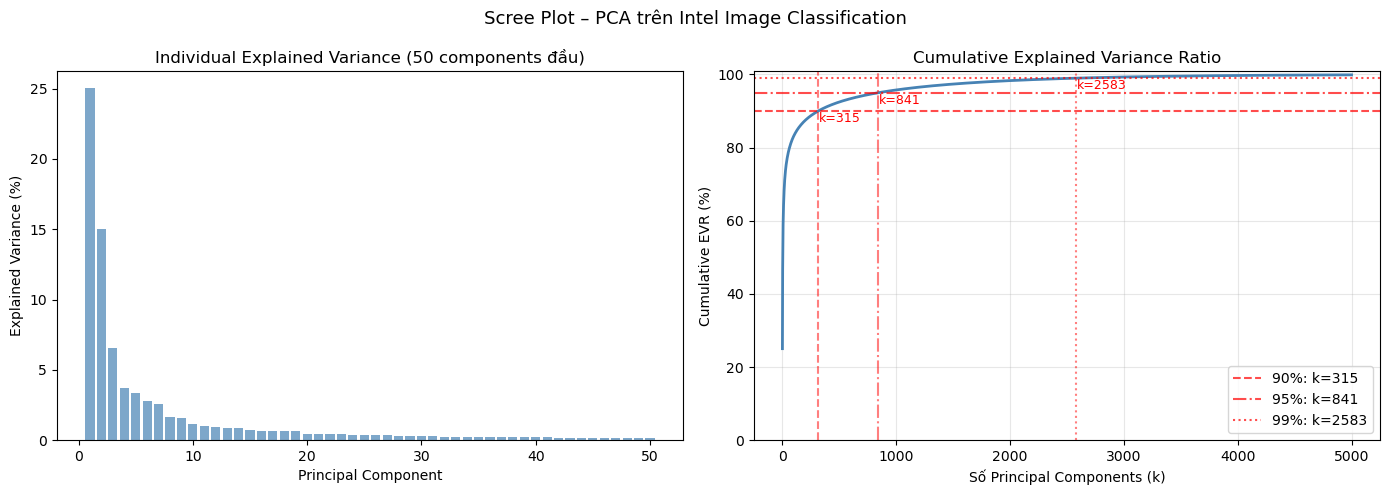

In [26]:
# Bước 2 – Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot trái: Individual EVR (50 components đầu) ---
ax1.bar(range(1, 51), 
        pca_full.explained_variance_ratio_[:50] * 100,
        color='steelblue', alpha=0.7)
ax1.set_title('Individual Explained Variance (50 components đầu)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')

# --- Plot phải: Cumulative EVR ---
ax2.plot(range(1, len(cumulative_evr) + 1), cumulative_evr * 100,
         color='steelblue', linewidth=2)

# Đánh dấu các ngưỡng
line_styles = ['--', '-.', ':']
for (t, k), ls in zip(k_stars.items(), line_styles):
    ax2.axhline(t * 100, color='red', linestyle=ls, alpha=0.7,
                label=f'{t*100:.0f}%: k={k}')
    ax2.axvline(k, color='red', linestyle=ls, alpha=0.5)
    ax2.annotate(f'k={k}', xy=(k, t*100),
                 xytext=(k+5, t*100 - 3),
                 fontsize=9, color='red')

ax2.set_title('Cumulative Explained Variance Ratio')
ax2.set_xlabel('Số Principal Components (k)')
ax2.set_ylabel('Cumulative EVR (%)')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 101)
ax2.grid(alpha=0.3)

plt.suptitle('Scree Plot – PCA trên Intel Image Classification', fontsize=13)
plt.tight_layout()
plt.show()

**Phân tích kết quả Scree Plot và Cumulative Explained Variance:**

**Scree Plot (trái):**
- PC1 giải thích ~25% và PC2 giải thích ~15% phương sai → 2 thành phần đầu tiên đã chiếm ~40% tổng phương sai
- Đường cong giảm nhanh từ PC1 đến PC5, sau đó giảm dần và tiệm cận 0 từ PC20 trở đi → đây là dấu hiệu đặc trưng của dữ liệu ảnh pixel thô: thông tin tập trung ở một số ít thành phần đầu nhưng vẫn còn phân tán ở rất nhiều thành phần sau

**Cumulative Explained Variance (phải):**
- Cần **315 components** để giải thích **90%** phương sai
- Cần **841 components** để giải thích **95%** phương sai  
- Cần **2583 components** để giải thích **99%** phương sai

**Kết luận:**
- Dữ liệu ảnh pixel thô có **độ phức tạp cao**, thông tin không tập trung vào ít chiều mà phân tán rất nhiều → cần số lượng components lớn để bảo toàn thông tin
- So sánh với tổng số chiều ban đầu là **12288** (64×64×3), cần 315 components để giữ 90% thông tin → giảm được ~97% số chiều mà vẫn bảo toàn phần lớn thông tin
- Trong thực tế, nên chọn **k = 315** (90%) làm điểm cân bằng giữa giảm chiều và bảo toàn thông tin khi dùng PCA làm bước tiền xử lý cho các mô hình downstream

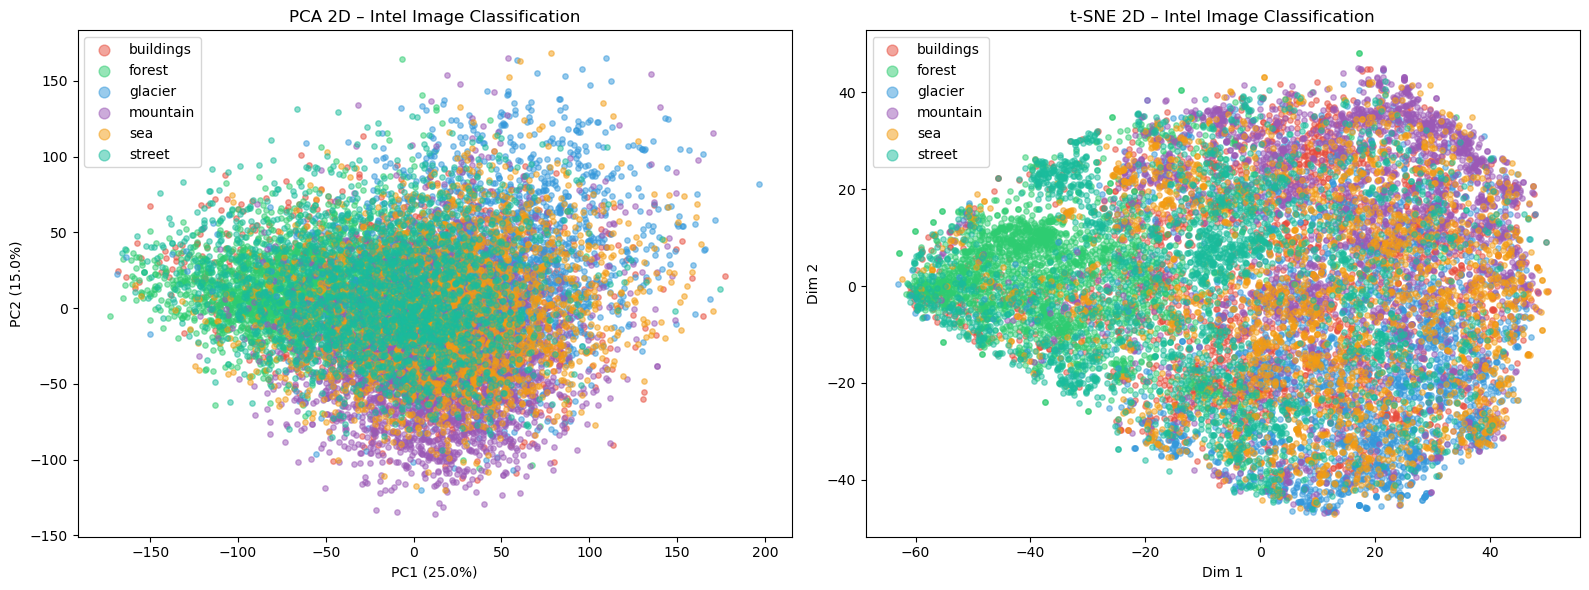

In [27]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# Lấy subset để t-SNE không quá chậm
X_sub, y_sub = sample_subset(X_scaled, y_train, n_per_class=500)

fig = plt.figure(figsize=(16, 6))

# PCA 2D - dùng X_sub
ax1 = fig.add_subplot(121)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)  # đổi X_scaled → X_sub
for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = y_train == i  # đổi y_train → y_sub
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=cls, alpha=0.5, s=15)
evr1 = pca_2d.explained_variance_ratio_[0] * 100
evr2 = pca_2d.explained_variance_ratio_[1] * 100
ax1.set_xlabel(f'PC1 ({evr1:.1f}%)')
ax1.set_ylabel(f'PC2 ({evr2:.1f}%)')
ax1.set_title('PCA 2D – Intel Image Classification')
ax1.legend(markerscale=2)

# t-SNE 2D (dùng subset)
ax2 = fig.add_subplot(122)
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30,n_jobs=-1)
X_tsne_2d = tsne_2d.fit_transform(X_scaled)
for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = y_train == i
    ax2.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                c=color, label=cls, alpha=0.5, s=15)
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_title('t-SNE 2D – Intel Image Classification')
ax2.legend(markerscale=2)

plt.tight_layout()
plt.show()

**Phân tích kết quả trực quan hóa PCA 2D và t-SNE 2D:**

**PCA 2D (trái):**
- PC1 (25%) và PC2 (15%) giải thích tổng cộng ~40% phương sai → phần lớn thông tin vẫn nằm ở các chiều còn lại
- Các lớp phân bố chồng chéo nhau nhiều, chưa hình thành cụm rõ ràng
- PCA là phép chiếu **tuyến tính**, không đủ khả năng tách biệt các lớp có ranh giới phi tuyến trong không gian pixel thô

**t-SNE 2D (phải):**
- t-SNE bảo toàn cấu trúc cục bộ tốt hơn PCA, các điểm cùng lớp có xu hướng tập trung hơn
- Lớp `forest` (xanh lá) hình thành cụm tương đối rõ ở phía trái → đặc trưng màu sắc xanh lá đặc trưng giúp phân biệt tốt
- Các lớp còn lại (`buildings`, `glacier`, `mountain`, `sea`, `street`) vẫn chồng chéo đáng kể → các lớp này có đặc trưng pixel tương đồng, khó phân biệt bằng pixel thô

**So sánh PCA và t-SNE:**
- t-SNE cho thấy cấu trúc cụm rõ hơn PCA nhờ khả năng học **quan hệ phi tuyến** giữa các điểm
- Tuy nhiên cả 2 đều cho thấy pixel thô chưa đủ phân biệt các lớp → cần deep feature (CNN) để tách biệt tốt hơn

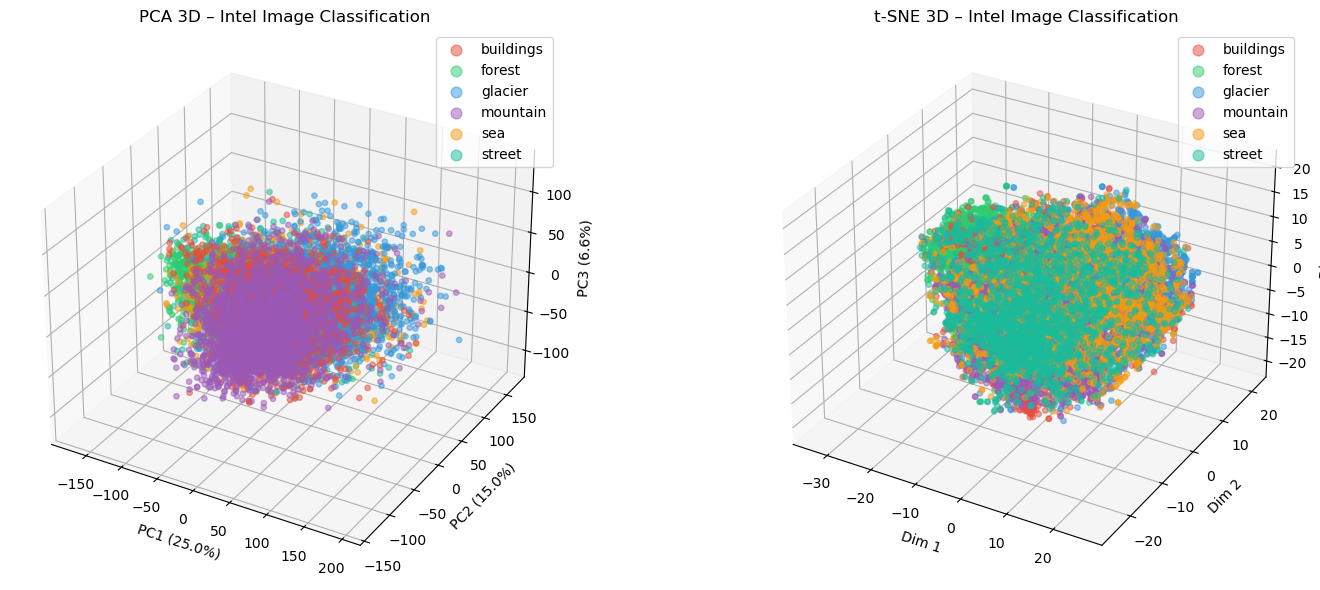

In [28]:
fig = plt.figure(figsize=(16, 6))

# PCA 3D
ax1 = fig.add_subplot(121, projection='3d')
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)
for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = y_train == i
    ax1.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                c=color, label=cls, alpha=0.5, s=15)
evr1 = pca_3d.explained_variance_ratio_[0] * 100
evr2 = pca_3d.explained_variance_ratio_[1] * 100
evr3 = pca_3d.explained_variance_ratio_[2] * 100
ax1.set_xlabel(f'PC1 ({evr1:.1f}%)')
ax1.set_ylabel(f'PC2 ({evr2:.1f}%)')
ax1.set_zlabel(f'PC3 ({evr3:.1f}%)')
ax1.set_title('PCA 3D – Intel Image Classification')
ax1.legend(markerscale=2)

# t-SNE 3D (dùng subset)
# Giảm chiều bằng PCA xuống 50 trước khi t-SNE
pca_pre = PCA(n_components=50, random_state=42)
X_pca_pre = pca_pre.fit_transform(X_scaled)

ax2 = fig.add_subplot(122, projection='3d')
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=50, n_jobs=-1)
X_tsne_3d = tsne_3d.fit_transform(X_pca_pre)
for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    mask = y_train == i
    ax2.scatter(X_tsne_3d[mask, 0], X_tsne_3d[mask, 1], X_tsne_3d[mask, 2],
                c=color, label=cls, alpha=0.5, s=15)
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
ax2.set_title('t-SNE 3D – Intel Image Classification')
ax2.legend(markerscale=2)

plt.tight_layout()
plt.show()

**Phân tích kết quả trực quan hóa PCA 3D và t-SNE 3D:**

**PCA 3D (trái):**
- PC1 (25%), PC2 (15%), PC3 (6.6%) giải thích tổng cộng ~46.6% phương sai
- Các lớp vẫn chồng chéo nhiều, chưa hình thành cụm rõ ràng → nhất quán với kết quả PCA 2D
- Thêm PC3 không cải thiện đáng kể khả năng tách biệt so với 2D → thông tin phân lớp không tập trung ở các thành phần đầu

**t-SNE 3D (phải):**
- So với t-SNE 2D, không gian 3D cho thấy cấu trúc phân bố dạng **hình cầu rỗng** → các lớp phân bố trên bề mặt của một khối cầu trong không gian 3D
- Các lớp vẫn chồng chéo nhau, chưa tách biệt rõ ràng
- t-SNE 3D được chạy sau khi giảm chiều bằng PCA 50 components để tránh numerical instability với dữ liệu 12288 chiều

**So sánh 2D và 3D:**
- Thêm chiều thứ 3 không cải thiện đáng kể khả năng tách biệt lớp ở cả PCA lẫn t-SNE
- Kết quả này củng cố kết luận rằng **pixel thô không đủ để phân biệt các lớp**, cần deep feature từ CNN để có biểu diễn tốt hơn

In [29]:
from sklearn.metrics import silhouette_score

sil_pca  = silhouette_score(X_pca_2d,  y_train, sample_size=1000, random_state=42)
sil_tsne = silhouette_score(X_tsne_2d, y_train, sample_size=1000, random_state=42)

print()
print("Diễn giải:")
print(f"  > 0.5  : Các lớp tách biệt tốt")
print(f"  0.2–0.5: Tách biệt trung bình")
print(f"  < 0.2  : Các lớp chồng chéo nhiều")

print("=" * 50)
print("KẾT QUẢ PHÂN TÍCH PCA")
print("=" * 50)
print(f"Tổng số chiều gốc        : {d}")
print(f"k* để giải thích 90% EVR : {k_stars[0.90]}")
print(f"k* để giải thích 95% EVR : {k_stars[0.95]}")
print(f"k* để giải thích 99% EVR : {k_stars[0.99]}")
print(f"Silhouette Score PCA 2D  : {sil_pca:.4f}")
print(f"Silhouette Score t-SNE   : {sil_tsne:.4f}")


Diễn giải:
  > 0.5  : Các lớp tách biệt tốt
  0.2–0.5: Tách biệt trung bình
  < 0.2  : Các lớp chồng chéo nhiều
KẾT QUẢ PHÂN TÍCH PCA
Tổng số chiều gốc        : 12288
k* để giải thích 90% EVR : 315
k* để giải thích 95% EVR : 841
k* để giải thích 99% EVR : 2583
Silhouette Score PCA 2D  : -0.0408
Silhouette Score t-SNE   : -0.0419


**Phân tích kết quả Silhouette Score:**

| Phương pháp | Silhouette Score |
|---|---|
| PCA 2D | -0.0408 |
| t-SNE 2D | -0.0419 |

**Nhận xét:**

Cả 2 phương pháp đều cho Silhouette Score **âm** (< 0), có nghĩa là các điểm dữ liệu **gần các điểm thuộc lớp khác hơn là lớp của chính mình** → các lớp chồng chéo nghiêm trọng trong không gian pixel thô.

Kết quả này hoàn toàn nhất quán với quan sát trực quan từ biểu đồ PCA và t-SNE ở trên, đồng thời giải thích tại sao accuracy của k-NN và Logistic Regression chỉ đạt ~45% thay vì cao hơn.

**Kết luận tổng thể:**
- Pixel thô (12288 chiều) **không phải biểu diễn tốt** cho bài toán phân loại ảnh cảnh vật
- Cần ít nhất **315 components PCA** để giữ 90% thông tin, cho thấy dữ liệu có độ phức tạp cao
- Để tách biệt tốt giữa các lớp, cần chuyển sang **deep feature** (CNN, ResNet,...) thay vì pixel thô

---
### 4f. [Nâng cao] Phát hiện cạnh + ANOVA một chiều

**Lý thuyết:**

Phát hiện cạnh (Edge Detection) là kỹ thuật trích xuất đặc trưng cục bộ trong ảnh số,
xác định các vị trí có sự thay đổi đột ngột về cường độ pixel. Các đặc trưng cạnh phản
ánh biên giới giữa các vùng ảnh khác nhau — thông tin quan trọng để phân biệt các lớp
đối tượng trong bài toán phân loại ảnh.

**1. Các bộ lọc phát hiện cạnh**

- **Sobel:** Tính xấp xỉ gradient của cường độ ảnh theo hai hướng ngang và dọc bằng
  hai kernel tích chập 3×3:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad
G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

  Độ lớn gradient tổng hợp:
$$G = \sqrt{G_x^2 + G_y^2}$$

  Tham số điều chỉnh được là **ksize** (kích thước kernel, thường là 3, 5, 7) —
  kernel lớn hơn phát hiện cạnh thô hơn nhưng ít nhạy với nhiễu hơn.

- **Prewitt:** Tương tự Sobel nhưng dùng trọng số đều nhau, không nhấn mạnh pixel
  trung tâm:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}, \quad
G_y = \begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ 1 & 1 & 1 \end{bmatrix}$$

  Prewitt ít nhạy hơn Sobel với nhiễu nhưng cũng kém chính xác hơn ở các cạnh
  mảnh. Tham số điều chỉnh: **ngưỡng nhị phân hóa** (threshold) sau khi tính G.

- **Canny:** Thuật toán phát hiện cạnh đa bước, được coi là chuẩn mực nhờ khả năng
  phát hiện cạnh mảnh và chính xác. Gồm 4 bước:
  1. **Làm mịn Gaussian** với độ lệch chuẩn σ để giảm nhiễu.
  2. **Tính gradient** theo hướng ngang và dọc (dùng Sobel).
  3. **Non-maximum suppression:** Giữ lại chỉ các điểm cực đại cục bộ theo
     hướng gradient, làm mỏng cạnh.
  4. **Hysteresis thresholding:** Dùng hai ngưỡng low_threshold và high_threshold
     để xác định cạnh mạnh và cạnh yếu:
     - Pixel có G > high_threshold → cạnh mạnh (giữ lại).
     - Pixel có low_threshold < G ≤ high_threshold → cạnh yếu (giữ nếu kề cạnh mạnh).
     - Pixel có G ≤ low_threshold → loại bỏ.

**2. Edge Density**

Edge Density đo tỉ lệ pixel được phát hiện là cạnh trên tổng số pixel của ảnh:

$$\text{Edge Density} = \frac{\sum_{h,w} \mathbb{1}[\text{edge}_{h,w} > 0]}{H \times W}$$

Trong đó:
- $\mathbb{1}[\cdot]$: hàm chỉ thị, bằng 1 nếu pixel đó là cạnh, 0 nếu không phải.
- $H \times W$: tổng số pixel của ảnh.

Edge Density nằm trong khoảng $[0, 1]$:
- Giá trị cao → ảnh có nhiều chi tiết, đường nét phức tạp (ví dụ: street, buildings).
- Giá trị thấp → ảnh có vùng đồng nhất lớn (ví dụ: sea, glacier).

**3. Kiểm định ANOVA một chiều**

ANOVA (Analysis of Variance) một chiều kiểm định xem trung bình Edge Density có
khác nhau có ý nghĩa thống kê giữa các lớp hay không, mà không cần chỉ định cụ thể
cặp lớp nào khác nhau.

**Giả thuyết thống kê:**
- $H_0$: $\mu_1 = \mu_2 = \cdots = \mu_K$ — Edge Density trung bình bằng nhau ở
  tất cả K lớp.
- $H_1$: Tồn tại ít nhất một cặp lớp có $\mu_i \neq \mu_j$ — Edge Density khác
  nhau có ý nghĩa giữa các lớp.

Thống kê F được tính từ tỉ lệ phương sai giữa các nhóm (between-group) so với
phương sai trong nội bộ nhóm (within-group):

$$F = \frac{\text{MS}_{\text{between}}}{\text{MS}_{\text{within}}} =
\frac{\sum_{k=1}^{K} n_k (\bar{x}_k - \bar{x})^2 / (K-1)}
{\sum_{k=1}^{K} \sum_{i=1}^{n_k} (x_{ki} - \bar{x}_k)^2 / (N-K)}$$

Trong đó:
- $\bar{x}_k$: trung bình Edge Density của lớp k.
- $\bar{x}$: trung bình toàn bộ.
- $n_k$: số ảnh của lớp k, $N$: tổng số ảnh.

Quyết định bác bỏ $H_0$ khi $p\text{-value} < \alpha = 0.05$, kết luận Edge Density
có sự khác biệt có ý nghĩa thống kê giữa các lớp.

**4. Tác động kỳ vọng đến phân loại**

Nếu ANOVA cho thấy Edge Density khác biệt đáng kể giữa các lớp, thông tin cạnh
có thể được dùng như đặc trưng phân biệt lớp hiệu quả:
- Các lớp tự nhiên (forest, mountain, glacier) thường có Edge Density thấp hơn
  do bề mặt đồng nhất.
- Các lớp nhân tạo (street, buildings) thường có Edge Density cao hơn do nhiều
  đường thẳng và góc cạnh.
- Kết quả này gợi ý rằng các đặc trưng cạnh có thể bổ sung cho các đặc trưng
  pixel thô trong pipeline phân loại.

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from scipy.stats import f_oneway
from skimage.filters import prewitt

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
COLORS = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

In [31]:
# Bước 1 – Hàm tính Edge Density
def edge_density(edge_map):
    """Tính tỉ lệ pixel cạnh / tổng pixel"""
    return np.sum(edge_map > 0) / edge_map.size

In [32]:
# Bước 2 – Áp dụng 3 bộ lọc với 2 bộ siêu tham số mỗi loại
def apply_all_detectors(img_rgb):
    """
    Nhận ảnh RGB (H,W,3), trả về dict {tên: edge_map}
    Mỗi detector có 2 bộ siêu tham số
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    results = {}

    # --- Sobel: thay đổi ksize ---
    for ksize in [3, 5]:
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize)
        mag = np.sqrt(gx**2 + gy**2)
        # Nhị phân hóa theo ngưỡng Otsu
        mag_uint8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, edge = cv2.threshold(mag_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        results[f'Sobel_k{ksize}'] = edge

    # --- Prewitt: thay đổi ngưỡng nhị phân hóa ---
    gray_float = gray.astype(np.float64)
    prewitt_h = ndimage.prewitt(gray_float, axis=0)
    prewitt_v = ndimage.prewitt(gray_float, axis=1)
    mag_prewitt = np.sqrt(prewitt_h**2 + prewitt_v**2)
    mag_prewitt_norm = cv2.normalize(mag_prewitt, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    for thresh in [30, 60]:
        _, edge = cv2.threshold(mag_prewitt_norm, thresh, 255, cv2.THRESH_BINARY)
        results[f'Prewitt_t{thresh}'] = edge

    # --- Canny: thay đổi low/high threshold ---
    for (low, high) in [(50, 150), (100, 200)]:
        edge = cv2.Canny(gray, low, high)
        results[f'Canny_{low}_{high}'] = edge

    return results

In [33]:
# Bước 3 – Tính Edge Density cho toàn bộ tập train
# X_train shape: (N, H, W, 3) — dùng lại từ load_images()
# Giới hạn mỗi lớp 200 ảnh cho nhanh
X_train, y_train = load_images('./seg_train/seg_train', size=(64,64), max_per_class=None)

DETECTOR_NAMES = ['Sobel_k3', 'Sobel_k5', 
                  'Prewitt_t30', 'Prewitt_t60', 
                  'Canny_50_150', 'Canny_100_200']

# density_by_class[detector][class_idx] = list of edge densities
density_by_class = {det: {i: [] for i in range(6)} for det in DETECTOR_NAMES}

for img, label in zip(X_train, y_train):
    edge_maps = apply_all_detectors(img)
    for det_name, edge_map in edge_maps.items():
        density_by_class[det_name][label].append(edge_density(edge_map))

print("✅ Tính Edge Density xong!")
for det in DETECTOR_NAMES:
    means = [np.mean(density_by_class[det][i]) for i in range(6)]
    print(f"\n{det}:")
    for cls, m in zip(CLASS_NAMES, means):
        print(f"  {cls:<12}: {m:.4f}")

Loading street: 100%|██████████| 2382/2382 [00:00<00:00, 2463.27it/s]


✅ Tính Edge Density xong!

Sobel_k3:
  buildings   : 0.2204
  forest      : 0.2423
  glacier     : 0.1718
  mountain    : 0.1499
  sea         : 0.1562
  street      : 0.2173

Sobel_k5:
  buildings   : 0.2239
  forest      : 0.2477
  glacier     : 0.1848
  mountain    : 0.1596
  sea         : 0.1698
  street      : 0.2230

Prewitt_t30:
  buildings   : 0.4589
  forest      : 0.5915
  glacier     : 0.3922
  mountain    : 0.3494
  sea         : 0.3551
  street      : 0.4643

Prewitt_t60:
  buildings   : 0.2568
  forest      : 0.2913
  glacier     : 0.1950
  mountain    : 0.1634
  sea         : 0.1756
  street      : 0.2481

Canny_50_150:
  buildings   : 0.2443
  forest      : 0.3262
  glacier     : 0.2136
  mountain    : 0.1813
  sea         : 0.1774
  street      : 0.2575

Canny_100_200:
  buildings   : 0.2123
  forest      : 0.2697
  glacier     : 0.1668
  mountain    : 0.1322
  sea         : 0.1338
  street      : 0.2222


In [34]:
# Bước 4 – Kiểm định ANOVA một chiều
print("\n" + "="*60)
print(f"{'Detector':<18} {'F-statistic':>14} {'p-value':>12} {'Kết luận':>20}")
print("="*60)

anova_results = {}
for det in DETECTOR_NAMES:
    groups = [density_by_class[det][i] for i in range(6)]
    F, p = f_oneway(*groups)
    anova_results[det] = {'F': F, 'p': p}
    conclusion = "✅ Phân biệt được" if p < 0.05 else "❌ Không phân biệt"
    print(f"{det:<18} {F:>14.4f} {p:>12.4e} {conclusion:>20}")


Detector              F-statistic      p-value             Kết luận
Sobel_k3                 842.8898   0.0000e+00     ✅ Phân biệt được
Sobel_k5                 668.6078   0.0000e+00     ✅ Phân biệt được
Prewitt_t30             1179.1896   0.0000e+00     ✅ Phân biệt được
Prewitt_t60              850.2785   0.0000e+00     ✅ Phân biệt được
Canny_50_150            1825.6007   0.0000e+00     ✅ Phân biệt được
Canny_100_200           1744.3077   0.0000e+00     ✅ Phân biệt được


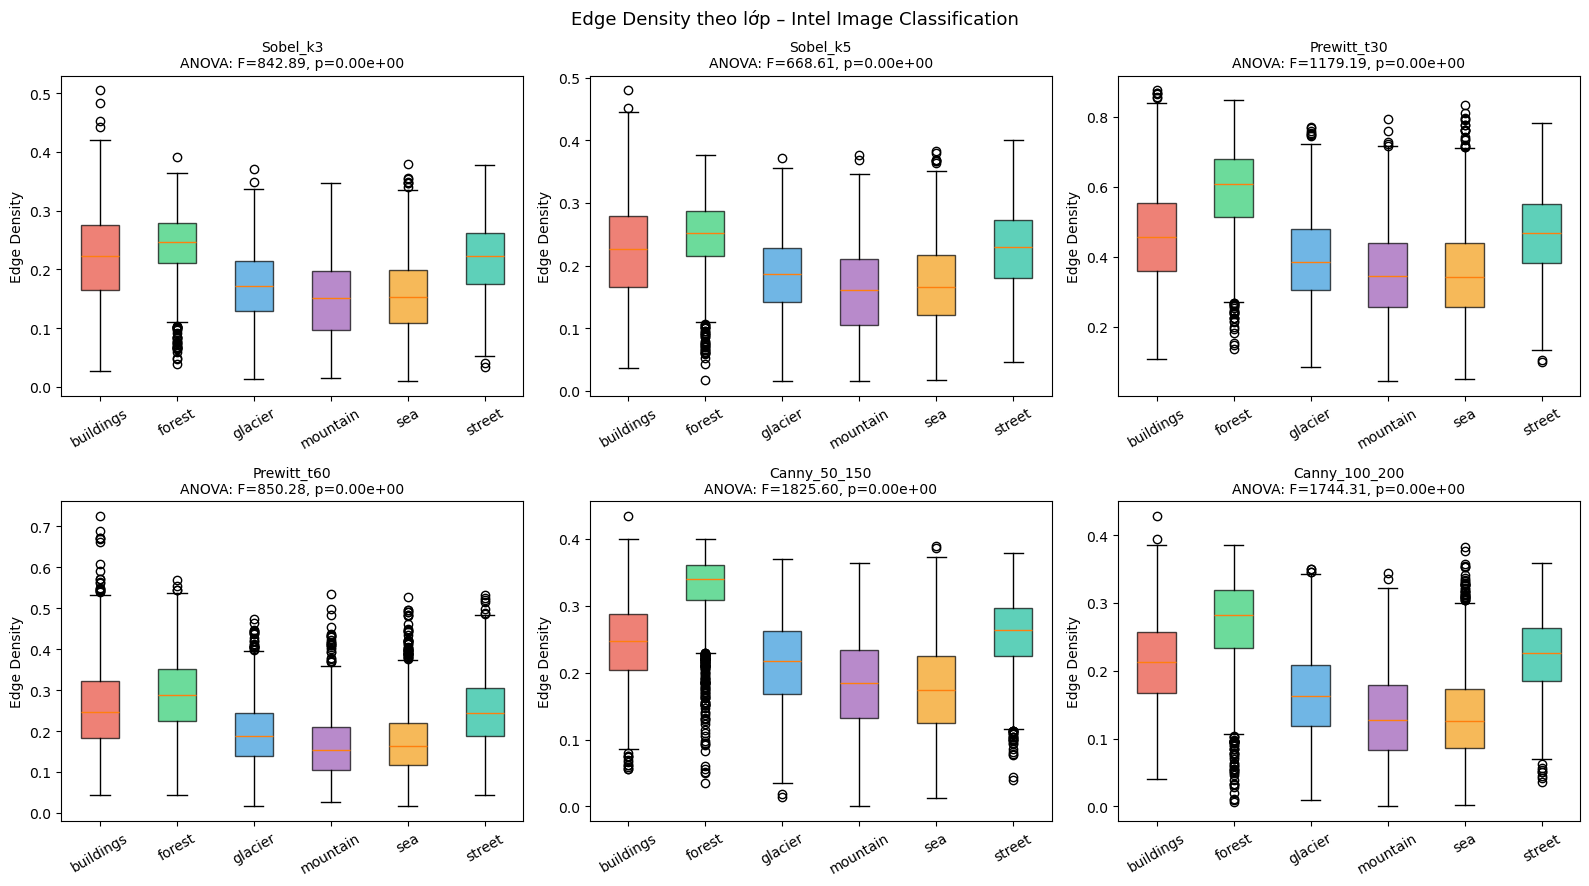

In [35]:
# Bước 5 – Boxplot Edge Density theo lớp
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, det in zip(axes, DETECTOR_NAMES):
    data_plot = [density_by_class[det][i] for i in range(6)]
    
    bp = ax.boxplot(data_plot, patch_artist=True, labels=CLASS_NAMES)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    F = anova_results[det]['F']
    p = anova_results[det]['p']
    ax.set_title(f'{det}\nANOVA: F={F:.2f}, p={p:.2e}', fontsize=10)
    ax.set_ylabel('Edge Density')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Edge Density theo lớp – Intel Image Classification', fontsize=13)
plt.tight_layout()
plt.show()

### Phân tích Edge Density theo lớp – ANOVA một chiều

#### Kết quả kiểm định ANOVA

| Bộ lọc | F-statistic | p-value | Kết luận |
|---|---|---|---|
| Sobel k=3 | 842.89 | 0.00 | Có sự khác biệt có ý nghĩa |
| Sobel k=5 | 668.61 | 0.00 | Có sự khác biệt có ý nghĩa |
| Prewitt t=30 | 1179.19 | 0.00 | Có sự khác biệt có ý nghĩa |
| Prewitt t=60 | 850.28 | 0.00 | Có sự khác biệt có ý nghĩa |
| Canny (50,150) | 1825.60 | 0.00 | Có sự khác biệt có ý nghĩa |
| Canny (100,200) | 1744.31 | 0.00 | Có sự khác biệt có ý nghĩa |

Tất cả 6 cấu hình đều cho p-value ≈ 0.00 << 0.05, bác bỏ H₀ (các lớp có edge density như nhau).
**Kết luận: thông tin cạnh có khả năng phân biệt các lớp một cách thống kê.**

#### Nhận xét theo từng lớp

- **`forest` (xanh lá):** Hành vi khác biệt rõ rệt nhất tùy bộ lọc.
  Với Sobel, edge density ở mức trung bình (~0.23–0.26), tương đương `buildings`.
  Với **Canny**, `forest` đột ngột có **edge density cao nhất** (~0.28–0.35),
  do Canny nhạy với các cạnh mịn của lá cây và kết cấu hữu cơ dày đặc.

- **`glacier` và `mountain` (tím và hồng):** Nhất quán có edge density **thấp nhất**
  trên mọi bộ lọc (~0.15–0.20 với Sobel/Prewitt, ~0.20 với Canny),
  phản ánh bề mặt mịn, ít chi tiết cục bộ của băng và địa hình núi.

- **`buildings` (đỏ cam):** Edge density cao và **phương sai lớn** trên Prewitt (t=30),
  do ảnh đô thị chứa nhiều cạnh thẳng nhưng mức độ chi tiết biến động mạnh
  giữa các ảnh (góc chụp, mật độ công trình khác nhau).

- **`sea` (vàng):** Edge density thấp với Sobel/Prewitt (~0.15–0.20)
  nhưng tăng đáng kể với Canny — cho thấy biển có ít gradient mạnh
  nhưng nhiều cạnh mịn (sóng, đường chân trời).

- **`street` (xanh cyan):** Edge density trung bình–cao, tương đồng với `buildings`,
  hợp lý vì ảnh đường phố cũng chứa nhiều cạnh nhân tạo.

#### Nhận xét về bộ lọc

- **Canny** cho F-statistic cao nhất (1825.60 và 1744.31) → **phân biệt lớp tốt nhất**,
  vì ngưỡng kép của Canny loại bỏ nhiễu hiệu quả và chỉ giữ cạnh thực sự có ý nghĩa.
- **Prewitt t=30** đứng thứ hai (F=1179.19), nhạy hơn Sobel do ngưỡng thấp hơn.
- **Sobel k=5** thấp hơn Sobel k=3, cho thấy kernel lớn hơn làm mờ cạnh
  và giảm khả năng phân biệt.

#### Kết luận tổng quát

Thông tin cạnh **có giá trị phân biệt lớp** trên tập Intel Image Classification,
đặc biệt với bộ lọc Canny. Cặp lớp dễ phân biệt nhất qua edge density là
`glacier`/`mountain` (thấp) vs `forest` (cao với Canny).
Tuy nhiên, sự chồng chéo vẫn còn lớn giữa `buildings`, `street` và `forest` với Sobel/Prewitt,
nên edge density nên được dùng kết hợp với đặc trưng màu sắc và kết cấu thay vì dùng độc lập.

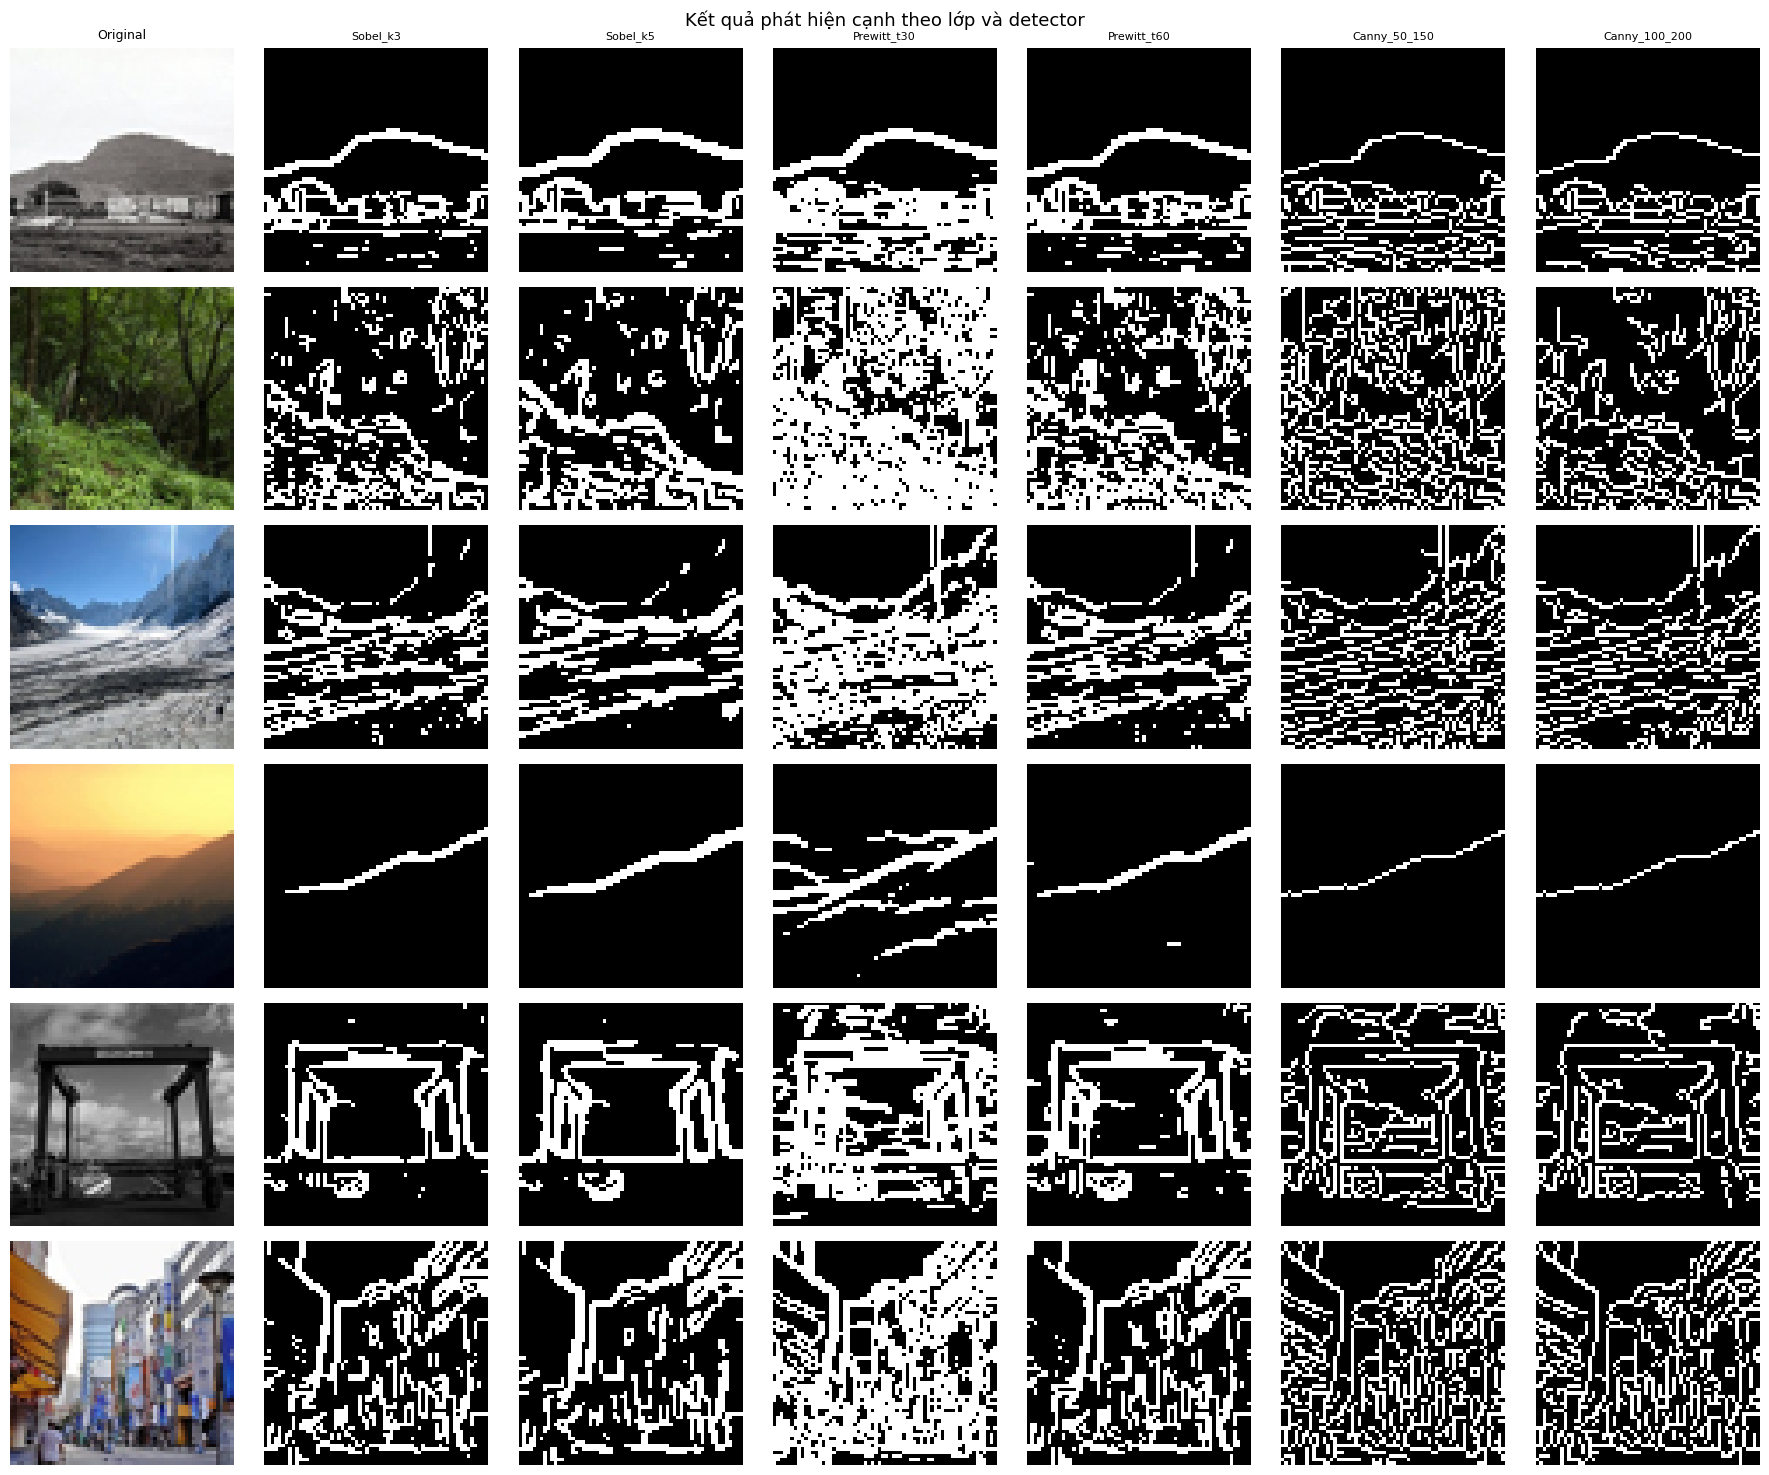

In [36]:
# Bước 6 – Trực quan hóa ảnh cạnh mẫu
# Lấy 1 ảnh mẫu mỗi lớp để minh họa
sample_per_class = {}
for img, label in zip(X_train, y_train):
    if label not in sample_per_class:
        sample_per_class[label] = img
    if len(sample_per_class) == 6:
        break

fig, axes = plt.subplots(6, 7, figsize=(18, 15))
col_titles = ['Original'] + DETECTOR_NAMES

for i in range(6):
    img = sample_per_class[i]
    edge_maps = apply_all_detectors(img)
    
    # Cột 0: ảnh gốc
    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(CLASS_NAMES[i], fontsize=10, fontweight='bold')
    if i == 0:
        axes[i, 0].set_title('Original', fontsize=9)
    axes[i, 0].axis('off')
    
    # Cột 1-6: các edge map
    for j, det in enumerate(DETECTOR_NAMES):
        axes[i, j+1].imshow(edge_maps[det], cmap='gray')
        if i == 0:
            axes[i, j+1].set_title(det, fontsize=8)
        axes[i, j+1].axis('off')

plt.suptitle('Kết quả phát hiện cạnh theo lớp và detector', fontsize=13)
plt.tight_layout()
plt.show()

In [37]:
# Bước 7 – Tóm tắt kết quả
print("\n" + "="*50)
print("KẾT LUẬN PHÂN TÍCH EDGE DENSITY")
print("="*50)

for det in DETECTOR_NAMES:
    p = anova_results[det]['p']
    means = {CLASS_NAMES[i]: np.mean(density_by_class[det][i]) for i in range(6)}
    top_high = max(means, key=means.get)
    top_low  = min(means, key=means.get)
    
    print(f"\n[{det}]")
    print(f"  ANOVA p-value : {p:.4e} → {'Có' if p < 0.05 else 'Không'} khác biệt đáng kể")
    print(f"  Lớp cạnh nhiều nhất : {top_high} ({means[top_high]:.4f})")
    print(f"  Lớp cạnh ít nhất    : {top_low}  ({means[top_low]:.4f})")


KẾT LUẬN PHÂN TÍCH EDGE DENSITY

[Sobel_k3]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.2423)
  Lớp cạnh ít nhất    : mountain  (0.1499)

[Sobel_k5]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.2477)
  Lớp cạnh ít nhất    : mountain  (0.1596)

[Prewitt_t30]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.5915)
  Lớp cạnh ít nhất    : mountain  (0.3494)

[Prewitt_t60]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.2913)
  Lớp cạnh ít nhất    : mountain  (0.1634)

[Canny_50_150]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.3262)
  Lớp cạnh ít nhất    : sea  (0.1774)

[Canny_100_200]
  ANOVA p-value : 0.0000e+00 → Có khác biệt đáng kể
  Lớp cạnh nhiều nhất : forest (0.2697)
  Lớp cạnh ít nhất    : mountain  (0.1322)


### Phân tích Edge Density theo lớp – ANOVA một chiều

#### Kết quả kiểm định ANOVA

| Bộ lọc | F-statistic | p-value | Lớp cao nhất | Lớp thấp nhất |
|---|---|---|---|---|
| Sobel k=3 | 842.89 | 0.00 | forest (0.2423) | mountain (0.1499) |
| Sobel k=5 | 668.61 | 0.00 | forest (0.2477) | mountain (0.1596) |
| Prewitt t=30 | 1179.19 | 0.00 | forest (0.5915) | mountain (0.3494) |
| Prewitt t=60 | 850.28 | 0.00 | forest (0.2913) | mountain (0.1634) |
| Canny (50,150) | 1825.60 | 0.00 | forest (0.3262) | sea (0.1774) |
| Canny (100,200) | 1744.31 | 0.00 | forest (0.2697) | mountain (0.1322) |

Tất cả 6 cấu hình đều cho p-value ≈ 0.00 << 0.05, bác bỏ H₀ (các lớp có edge density như nhau).  
**Kết luận: thông tin cạnh có khả năng phân biệt các lớp một cách có ý nghĩa thống kê.**

#### Nhận xét theo từng lớp

- **`forest` (xanh lá):** Có edge density **cao nhất nhất quán trên toàn bộ 6 cấu hình**,
  dao động từ 0.2423 (Sobel k=3) đến 0.5915 (Prewitt t=30).
  Kết cấu hữu cơ dày đặc của lá cây tạo ra vô số cạnh mịn ở mọi hướng,
  khiến bất kỳ bộ lọc cạnh nào cũng phát hiện được mật độ cao.

- **`mountain` (hồng):** Có edge density **thấp nhất trên 5/6 cấu hình**,
  từ 0.1322 (Canny 100,200) đến 0.3494 (Prewitt t=30).
  Bề mặt núi có gradient chuyển tiếp mượt, ít chi tiết cục bộ sắc nét,
  nên các bộ lọc phát hiện được ít cạnh hơn đáng kể.

- **`sea` (vàng):** Thấp nhất với Canny (50,150) ở mức 0.1774, thay thế `mountain`.
  Mặt biển có ít cạnh rõ ràng; Canny với ngưỡng cao (50,150) lọc bỏ
  hầu hết nhiễu sóng, chỉ giữ lại đường chân trời → edge density rất thấp.

- **`buildings` và `street`:** Edge density trung bình–cao, tương đồng nhau
  trên mọi bộ lọc, hợp lý vì cả hai lớp đều chứa nhiều cạnh nhân tạo thẳng.

#### Kết luận tổng quát

Thông tin cạnh **có giá trị phân biệt lớp rõ ràng** trên tập Intel Image Classification.
Cặp lớp phân biệt tốt nhất qua edge density là `forest` (cao nhất) và `mountain`/`sea` (thấp nhất),
với khoảng cách lên đến ~2× về giá trị trung bình edge density.
Tuy nhiên, sự chồng chéo vẫn đáng kể giữa `buildings`, `street` và `forest` ở Sobel/Prewitt,
do đó edge density nên được kết hợp với đặc trưng màu sắc và kết cấu thay vì sử dụng độc lập.

---
<a id='5'></a>
## 5. Tổng hợp kết quả Ablation Study

In [38]:
final_ablation = {}

# --- Ý a: Baseline (full data) ---
for size in size_config:
    key = f'Baseline ({size}×{size} RGB)'
    final_ablation[f'[a] {key}'] = ablation_results_a[key]

# --- Ý b: Color space ---
for cs_name, acc in colorspace_acc.items():
    final_ablation[f'[b] {cs_name}'] = acc

# --- Ý c: Normalization ---
label_map = {
    'Raw':               '[c] Raw',
    'minmax_01':         '[c] MinMax [0,1]',
    'minmax_11':         '[c] MinMax [-1,1]',
    'zscore_global':     '[c] Z-score Global',
    'zscore_perchannel': '[c] Z-score Per-ch',
}
for key, val in ablation_results.items():
    if key in label_map:
        final_ablation[label_map[key]] = val['k-NN Acc']

# --- Ý d: Augmentation ---
final_ablation['[d] Original']           = knn_orig
final_ablation['[d] Augmented Only']     = knn_aug
final_ablation['[d] Original+Augmented'] = knn_comb

# --- Baseline riêng cho từng nhóm ---
# Lấy từ chính data đã tính
group_baselines = {
    '[a]': ablation_results_a['Baseline (150×150 RGB)'],
    '[b]': colorspace_acc.get('RGB', baseline_acc),   # RGB là baseline của [b]
    '[c]': ablation_results['Raw']['k-NN Acc'],        # Raw là baseline của [c]
    '[d]': knn_orig,                                   # Original là baseline của [d]
}

# --- Tạo DataFrame ---
df_final = pd.DataFrame(
    final_ablation.items(),
    columns=['Kỹ thuật', 'k-NN Accuracy']
)

# --- Xác định nhóm ---
group_order = {'[a]': 0, '[b]': 1, '[c]': 2, '[d]': 3}
df_final['_group_key'] = df_final['Kỹ thuật'].apply(
    lambda x: next((k for k in group_order if k in x), '[a]')
)
df_final['_group_ord'] = df_final['_group_key'].map(group_order)

# --- Tính Δ so với baseline của từng nhóm ---
df_final['Baseline nhóm'] = df_final['_group_key'].map(group_baselines)
df_final['Δ vs Baseline'] = df_final['k-NN Accuracy'] - df_final['Baseline nhóm']
df_final['Δ%'] = df_final['Δ vs Baseline'].apply(lambda x: f"{x*100:+.2f}%")

# --- Sort: nhóm a→d, trong nhóm sort accuracy giảm dần ---
df_final = (df_final
            .sort_values(['_group_ord', 'k-NN Accuracy'], ascending=[True, False])
            .reset_index(drop=True)
            .drop(columns=['_group_key', '_group_ord', 'Baseline nhóm']))

# --- Hiển thị ---
print("=== BẢNG TỔNG HỢP ABLATION STUDY ===")

display(df_final.style
        .highlight_max(subset=['k-NN Accuracy'], color='#1abc9c')
        .highlight_min(subset=['k-NN Accuracy'], color='#e91e63')
        .format({'k-NN Accuracy': '{:.4f}', 'Δ vs Baseline': '{:+.4f}'})
        .apply(lambda col: [
            'color: #27ae60' if '+' in str(v) else
            'color: #e91e63' if '-' in str(v) else ''
            for v in col
        ], subset=['Δ%']))

=== BẢNG TỔNG HỢP ABLATION STUDY ===


,Kỹ thuật,k-NN Accuracy,Δ vs Baseline,Δ%
0,[a] Baseline (32×32 RGB),0.4419,+0.0774,+7.74%
1,[a] Baseline (64×64 RGB),0.4207,+0.0562,+5.62%
2,[a] Baseline (128×128 RGB),0.3962,+0.0317,+3.17%
3,[a] Baseline (150×150 RGB),0.3645,+0.0000,+0.00%
4,[b] HSV,0.4451,+0.0417,+4.17%
5,[b] RGB,0.4034,+0.0000,+0.00%
6,[b] LAB,0.3894,-0.0139,-1.39%
7,[b] Grayscale,0.2972,-0.1062,-10.62%
8,[c] Z-score Per-ch,0.3537,+0.0003,+0.03%
9,[c] Raw,0.3533,+0.0000,+0.00%


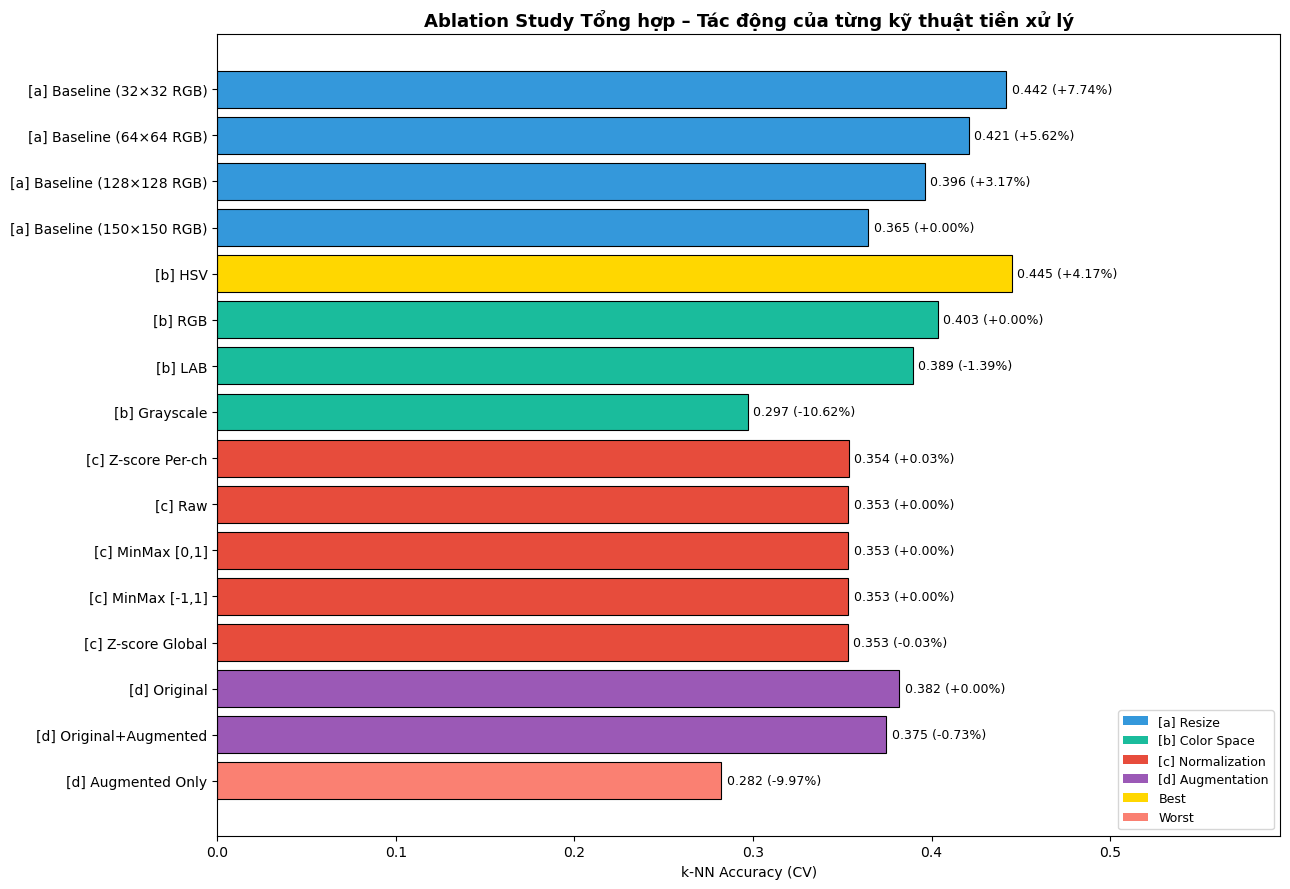

In [39]:
fig, ax = plt.subplots(figsize=(13, 9))

# Đổi màu: xanh lá → teal (#1abc9c), dễ nhìn hơn
def get_color(technique, acc, max_acc, min_acc):
    if acc == max_acc: return 'gold'
    if acc == min_acc: return 'salmon'
    if '[a]' in technique: return '#3498db'   # xanh dương
    if '[b]' in technique: return '#1abc9c'   # teal (thay xanh lá)
    if '[c]' in technique: return '#e74c3c'   # đỏ
    if '[d]' in technique: return '#9b59b6'   # tím
    return 'gray'

max_acc = df_final['k-NN Accuracy'].max()
min_acc = df_final['k-NN Accuracy'].min()

colors_bar = [get_color(t, v, max_acc, min_acc)
              for t, v in zip(df_final['Kỹ thuật'], df_final['k-NN Accuracy'])]

# Vẽ theo thứ tự a→b→c→d (invert vì barh đọc từ dưới lên)
bars = ax.barh(df_final['Kỹ thuật'][::-1], 
               df_final['k-NN Accuracy'][::-1],
               color=colors_bar[::-1],
               edgecolor='black', linewidth=0.8)

for bar, val, delta in zip(bars, 
                            df_final['k-NN Accuracy'][::-1], 
                            df_final['Δ%'][::-1]):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f} ({delta})', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='[a] Resize'),
    Patch(facecolor='#1abc9c', label='[b] Color Space'),
    Patch(facecolor='#e74c3c', label='[c] Normalization'),
    Patch(facecolor='#9b59b6', label='[d] Augmentation'),
    Patch(facecolor='gold',    label='Best'),
    Patch(facecolor='salmon',  label='Worst'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('k-NN Accuracy (CV)')
ax.set_xlim(0, max_acc + 0.15)
ax.set_title('Ablation Study Tổng hợp – Tác động của từng kỹ thuật tiền xử lý',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Nhận xét Ablation Study Tổng hợp

### 1. Tổng quan

Trong ablation study này, k-NN được đánh giá trên 4 nhóm yếu tố:
kích thước ảnh, không gian màu, chuẩn hóa, và augmentation.
Kỹ thuật tốt nhất đạt **0.4450 accuracy** ([b] HSV),
trong khi kỹ thuật kém nhất chỉ đạt **0.2823** ([d] Augmented Only).

---

### 2. Nhận xét theo từng nhóm

#### [a] Resize – Kích thước nhỏ cho kết quả tốt hơn

| Kích thước | Accuracy | Δ vs Baseline (150×150) |
|---|---|---|
| 32×32 | **0.4419** | +7.74% ✓ |
| 64×64 | 0.4207 | +5.62% |
| 128×128 | 0.3962 | +3.17% |
| 150×150 | 0.3645 | ±0.00% |

- Accuracy **giảm dần khi tăng kích thước** — ngược với trực giác nhưng
  hợp lý với k-NN: ảnh lớn hơn tạo vector chiều cao hơn, khiến khoảng
  cách Euclidean bị pha loãng (curse of dimensionality).
- **32×32 là kích thước tối ưu** cho k-NN trên tập này (+7.74% so với 150×150).

#### [b] Color Space – Nhóm có tác động lớn nhất

| Không gian màu | Accuracy | Δ vs Baseline (RGB) |
|---|---|---|
| HSV | **0.4450** | +4.17% ✓ |
| RGB | 0.4034 | ±0.00% |
| LAB | 0.3894 | −1.39% |
| Grayscale | 0.2973 | −10.61% ✗ |

- **HSV vượt trội nhất (+4.17%)** vì tách biệt thông tin màu sắc (Hue)
  khỏi độ sáng (Value), giúp k-NN đo khoảng cách ý nghĩa hơn trên
  ảnh phong cảnh có đặc trưng màu rõ ràng (rừng xanh, biển xanh, tuyết trắng).
- **Grayscale mất nhiều nhất (−10.61%)** do loại bỏ hoàn toàn thông tin màu —
  yếu tố phân biệt quan trọng nhất của dataset phong cảnh.
- LAB dù được thiết kế perceptually uniform nhưng lại kém RGB,
  có thể do k-NN không khai thác được đặc tính này qua khoảng cách Euclidean thô.

#### [c] Normalization – Tác động không đáng kể

| Phương pháp | Accuracy | Δ vs Baseline (Raw) |
|---|---|---|
| Z-score Per-channel | **0.3537** | +0.03% |
| Raw | 0.3533 | ±0.00% |
| MinMax [0,1] | 0.3533 | ±0.00% |
| MinMax [−1,1] | 0.3533 | ±0.00% |
| Z-score Global | 0.3530 | −0.03% |

- Tất cả phương pháp chuẩn hóa cho kết quả **gần như đồng nhất**
  (chênh lệch tối đa chỉ 0.03%), cho thấy k-NN không nhạy cảm
  với scale trong trường hợp này.
- Có thể do dữ liệu ảnh uint8 [0–255] đã phân phối tương đối đồng đều,
  nên chuẩn hóa không mang lại lợi ích thực sự.

#### [d] Augmentation – Có hại với k-NN

| Phương pháp | Accuracy | Δ vs Baseline (Original) |
|---|---|---|
| Original | **0.3820** | ±0.00% |
| Original + Augmented | 0.3747 | −0.73% |
| Augmented Only | 0.2823 | −9.97% ✗ |

- Augmentation **làm giảm accuracy** — hoàn toàn hợp lý với k-NN vì
  ảnh augmented (xoay, lật, nhiễu) tạo ra các điểm "giả" trong không gian
  pixel, làm lệch neighbor thực sự.
- **Augmented Only tệ nhất (−9.97%)** vì k-NN chỉ thấy ảnh biến đổi,
  mất đi phân phối gốc.
- Augmentation phát huy tác dụng với deep learning (học được invariance),
  không phù hợp với k-NN dựa trên khoảng cách pixel thô.

---

### 3. Kết luận

| Nhóm | Kỹ thuật tốt nhất | Mức cải thiện |
|---|---|---|
| [a] Resize | 32×32 | +7.74% vs 150×150 |
| [b] Color Space | HSV | +4.17% vs RGB |
| [c] Normalization | (không đáng kể) | ≤ 0.03% |
| [d] Augmentation | Không dùng | tránh −9.97% |

> **Khuyến nghị:** Với k-NN trên tập ảnh phong cảnh, ưu tiên dùng
> **ảnh nhỏ (32×32) + không gian màu HSV**, bỏ qua augmentation.
> Chuẩn hóa không ảnh hưởng đáng kể nên có thể giữ nguyên Raw để
> đơn giản hóa pipeline.